In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import Estimator
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms import VarQITE
from qiskit_algorithms.time_evolvers import TimeEvolutionProblem
from qiskit_algorithms.time_evolvers.variational import ImaginaryMcLachlanPrinciple
import time
from itertools import product


# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

VERBOSE = False

# ============================================================
# IM DRIVE BASE DATA
# ============================================================

# ---- 3-phase supply settings (used only when mode="threephase") ----
V_phase_rms = 80.0
f_e = 60.0
phase_offset = 0.0

# ---- Motor base parameters ----
L_s = 0.25
L_r = 0.25
p_p = 2
J = 0.003

# ---- Rated parameters used INSIDE controller (fixed model) ----
R_s_ctl = 2.3
R_r_ctl = 2.5
L_m_ctl = 0.24

# ---- Actual plant parameters (mismatch scenario) ----
T_ref = 25.0
alpha_Cu = 0.00393

R_s_ref = 2.3
R_r_ref = 2.5

T_C = 25.0
R_s = R_s_ref * (1.0 + alpha_Cu * (T_C - T_ref))
R_r = R_r_ref * (1.0 + alpha_Cu * (T_C - T_ref))

Lm_nom = 0.24
sat_case = "vstrong"   # "none", "mild", "strong"

if sat_case == "none":
    L_m = Lm_nom
elif sat_case == "mild":
    L_m = 0.90 * Lm_nom
elif sat_case == "strong":
    L_m = 0.75 * Lm_nom
elif sat_case == "vstrong":
    L_m = 0.5 * Lm_nom   # 50% drop
else:
    raise ValueError("Unknown sat_case")

print(f"[PLANT] Using T={T_C}°C: R_s={R_s:.4f}, R_r={R_r:.4f}")
print(f"[PLANT] Saturation case={sat_case}: L_m={L_m:.4f}")
print(f"[CTRL ] Rated params: R_s={R_s_ctl:.4f}, R_r={R_r_ctl:.4f}, L_m={L_m_ctl:.4f}")

# ---- Initial condition: x = [i_sα, i_sβ, λ_rα, λ_rβ, ω] ----
psi_const = 0.9
X0_GLOBAL = np.array([0.0, 0.0, psi_const, 0.0, 0.0], dtype=float)

psi_floor = 1e-3
np.random.seed(0)
# ============================================================
# ONLINE FRAMEWORK SETTINGS
# ============================================================

# Parameters to optimize online:
# p = [k_psi, k_w, theta_psi, theta_w]
PARAM_NAMES = ["k_psi", "k_w", "theta_psi", "theta_w"]

# Search box
P_MIN_GLOBAL = np.array([-100.0,   -100.0,   0.01,  0.01], dtype=float)
P_MAX_GLOBAL = np.array([1000.0, 1000.0, 100.0, 100.0], dtype=float)

# Stage 1: Black Hole
BH_POP_SIZE = 5
BH_MAX_ITERS = 10
BH_FREEZE_WIDTH = 10.0

# Online decision loop
T_TOTAL = 2.2
DT_DECISION = 0.2

# Horizon cost
T_HORIZON_COST = 0.05
N_TIME_COST = 20

# Cost weights
W_EPSI = 2.0
W_EW   = 10.0
W_EI   = 10.0
W_U    = 0.01
W_LYAP = 1.0

QUBO_SOLVER = "classic"     # "qite", "bruteforce", "classic"

# QITE
QITE_TAU = 2.0
QITE_STEPS = 5
QITE_REPS = 1
QITE_SEED_BASE = 4

# Classical local-search settings
CLASSIC_NUM_RESTARTS = 10
CLASSIC_MAX_FLIPS = 100
CLASSIC_SEED_BASE = 123

# Hamiltonian fit sampling
TRAIN_SAMPLE_FACTOR = 1
MIN_TRAIN_SAMPLES = 12
TOP_K_CANDIDATES = 8

# Bit allocation
BIT_WIDTH_THRESHOLDS = [5.0, 20.0]
BIT_ALLOCATION = [2, 3, 4]
MAX_BITS_PER_PARAM = 4

# ============================================================
# REFERENCE / LOAD SETTINGS
# ============================================================

mode = "controller"   # "controller" or "threephase"

# ---- Speed reference ----
w_type = "profile"  # "step","ramp","sine","profile","custom"

w_step = 200.0
w_ramp_t0 = 0.1
w_ramp_t1 = 0.8
w_ramp_slope = 250.0

w_sine_amp = 50.0
w_sine_bias = 150.0
w_sine_freq_hz = 1.0

w_profile = (
    (0.0, 0.4, 0.0, 200.0),
    (0.4, 0.7, 200.0, 200.0),
    (0.7, 1.2, 200.0, 500.0),
    (1.2, 1.6, 500.0, 500.0),
    (1.6, 2.1, 500.0, 0.0),
)

def w_custom(t: float):
    w = 100.0 + 50.0*np.sin(2*np.pi*0.5*t)
    dw = 50.0*(2*np.pi*0.5)*np.cos(2*np.pi*0.5*t)
    ddw = -50.0*(2*np.pi*0.5)**2*np.sin(2*np.pi*0.5*t)
    return w, dw, ddw

# ---- Flux reference ----
psi_type = "constant"  # "constant","step","ramp","sine","custom"
psi_step_t0 = 0.1
psi_step = 0.9

psi_ramp_t0 = 0.1
psi_ramp_t1 = 0.8
psi_ramp_slope = 0.2

psi_sine_amp = 0.1
psi_sine_bias = 0.8
psi_sine_freq_hz = 0.5

def psi_custom(t: float):
    psi = 0.9
    return psi, 0.0, 0.0

# ---- Load torque ----
TL_type = "step"  # "constant","step","sine","custom"
TL_const = 1.0

TL_step_t0 = 0.5
TL_step = 2.0

TL_sine_amp = 0.5
TL_sine_bias = 1.0
TL_sine_freq_hz = 1.0

def TL_custom(t: float):
    TL = 1.0
    return TL, 0.0

# ============================================================
# MOTOR COEFFICIENTS
# ============================================================

def motor_coeffs(Rs, Rr, Lm, Ls, Lr, p_p, J):
    L_sigma = Ls * (1.0 - (Lm**2) / (Ls * Lr))

    a_s = Rs / L_sigma + (Rr * Lm**2) / (Lr**2 * L_sigma)
    b_s = (Rr * Lm) / (Lr**2 * L_sigma)
    c_s = Lm / (L_sigma * Lr)

    alpha = (Rr * Lm) / Lr
    beta  = - Rr / Lr
    gamma = (3.0/2.0) * (p_p / J) * (Lm / Lr)

    return L_sigma, a_s, b_s, c_s, alpha, beta, gamma

# Plant coefficients
L_sigma_p, a_s_p, b_s_p, c_s_p, alpha_p, beta_p, gamma_p = motor_coeffs(
    R_s, R_r, L_m, L_s, L_r, p_p, J
)

# Controller nominal coefficients
L_sigma_c, a_s_c, b_s_c, c_s_c, alpha_c, beta_c, gamma_c = motor_coeffs(
    R_s_ctl, R_r_ctl, L_m_ctl, L_s, L_r, p_p, J
)

# ============================================================
# REFERENCES / LOAD
# ============================================================

def ref_step_fn(t: float, t_sw: float, value: float, bias: float = 0.0):
    r = bias + (value if t >= t_sw else 0.0)
    return r, 0.0, 0.0

def ref_ramp_fn(t: float, t0: float, t1: float, slope: float, bias: float = 0.0):
    if t < t0:
        return bias, 0.0, 0.0
    if t < t1:
        r = bias + slope*(t - t0)
        return r, slope, 0.0
    r = bias + slope*(t1 - t0)
    return r, 0.0, 0.0

def ref_sine_fn(t: float, amp: float, bias: float, freq_hz: float):
    w = 2.0*np.pi*freq_hz
    r = bias + amp*np.sin(w*t)
    dr = amp*w*np.cos(w*t)
    ddr = -amp*(w**2)*np.sin(w*t)
    return r, dr, ddr

def ref_piecewise_linear_fn(t: float, segments):
    t0_first, t1_first, y0_first, y1_first = segments[0]
    if t <= t0_first:
        return y0_first, 0.0, 0.0

    for (t0_, t1_, y0_, y1_) in segments:
        if t0_ <= t <= t1_:
            if abs(t1_ - t0_) < 1e-12:
                return y1_, 0.0, 0.0
            slope = (y1_ - y0_) / (t1_ - t0_)
            y = y0_ + slope*(t - t0_)
            return y, slope, 0.0

    return segments[-1][3], 0.0, 0.0

def speed_reference(t: float):
    if w_type == "step":
        return ref_step_fn(t, 0.0, w_step, 0.0)
    if w_type == "ramp":
        return ref_ramp_fn(t, w_ramp_t0, w_ramp_t1, w_ramp_slope, 0.0)
    if w_type == "sine":
        return ref_sine_fn(t, w_sine_amp, w_sine_bias, w_sine_freq_hz)
    if w_type == "profile":
        return ref_piecewise_linear_fn(t, w_profile)
    if w_type == "custom":
        return w_custom(t)
    raise ValueError(f"Unknown w_type: {w_type}")

def flux_reference(t: float):
    if psi_type == "constant":
        return psi_const, 0.0, 0.0
    if psi_type == "step":
        return ref_step_fn(t, psi_step_t0, psi_step, 0.0)
    if psi_type == "ramp":
        return ref_ramp_fn(t, psi_ramp_t0, psi_ramp_t1, psi_ramp_slope, 0.0)
    if psi_type == "sine":
        return ref_sine_fn(t, psi_sine_amp, psi_sine_bias, psi_sine_freq_hz)
    if psi_type == "custom":
        return psi_custom(t)
    raise ValueError(f"Unknown psi_type: {psi_type}")

def load_torque(t: float):
    if TL_type == "constant":
        return TL_const, 0.0
    if TL_type == "step":
        TL = TL_step if t >= TL_step_t0 else 0.0
        return TL, 0.0
    if TL_type == "sine":
        w_ = 2.0*np.pi*TL_sine_freq_hz
        TL = TL_sine_bias + TL_sine_amp*np.sin(w_*t)
        dTL = TL_sine_amp*w_*np.cos(w_*t)
        return TL, dTL
    if TL_type == "custom":
        return TL_custom(t)
    raise ValueError(f"Unknown TL_type: {TL_type}")

def three_phase_voltages(t: float, V_phase_rms: float, f_e: float, phase_offset: float = 0.0):
    w_ = 2.0 * np.pi * f_e
    Vp = np.sqrt(2.0) * V_phase_rms
    va = Vp * np.sin(w_*t + phase_offset)
    vb = Vp * np.sin(w_*t + phase_offset - 2.0*np.pi/3.0)
    vc = Vp * np.sin(w_*t + phase_offset + 2.0*np.pi/3.0)
    return va, vb, vc

def abc_to_alphabeta(va: float, vb: float, vc: float):
    v_alpha = (2.0/3.0) * (va - 0.5*vb - 0.5*vc)
    v_beta  = (2.0/3.0) * (np.sqrt(3.0)/2.0) * (vb - vc)
    return v_alpha, v_beta

def supply_u_alphabeta(t: float):
    va, vb, vc = three_phase_voltages(t, V_phase_rms, f_e, phase_offset)
    return abc_to_alphabeta(va, vb, vc)

def evaluate_true_cost_from_bitstring_im(bitstr, x0, t_start_abs, p_min, p_max, bits_per_param):
    k_psi, k_w, theta_psi, theta_w = decode_bitstring_to_params(
        bitstr, p_min, p_max, bits_per_param
    )
    J = simulate_horizon_cost_im(
        x0, k_psi, k_w, theta_psi, theta_w,
        t_start_abs=t_start_abs
    )
    return J

def brute_force_select_best_bitstring_on_H(H, num_qubits):
    best_s = None
    best_E = float("inf")

    for bits in product("01", repeat=num_qubits):
        s = "".join(bits)
        E = diagonal_hamiltonian_energy_of_bitstring(H, s)
        if E < best_E:
            best_s = s
            best_E = E

    return best_s, best_E

def random_bitstring(n, rng):
    return "".join(rng.choice(["0", "1"], size=n))

def flip_bit(s, idx):
    return s[:idx] + ("1" if s[idx] == "0" else "0") + s[idx+1:]

def classical_local_search_select_best_bitstring_on_H(
    H, num_qubits,
    num_restarts=CLASSIC_NUM_RESTARTS,
    max_flips=CLASSIC_MAX_FLIPS,
    seed=0
):
    rng = np.random.default_rng(seed)

    best_global_s = None
    best_global_E = float("inf")

    for _ in range(num_restarts):
        s = random_bitstring(num_qubits, rng)
        E = diagonal_hamiltonian_energy_of_bitstring(H, s)

        improved = True
        n_iter = 0

        while improved and n_iter < max_flips:
            improved = False
            n_iter += 1

            best_neighbor_s = s
            best_neighbor_E = E

            for j in range(num_qubits):
                s_try = flip_bit(s, j)
                E_try = diagonal_hamiltonian_energy_of_bitstring(H, s_try)
                if E_try < best_neighbor_E:
                    best_neighbor_s = s_try
                    best_neighbor_E = E_try

            if best_neighbor_E < E:
                s = best_neighbor_s
                E = best_neighbor_E
                improved = True

        if E < best_global_E:
            best_global_s = s
            best_global_E = E

    return best_global_s, best_global_E

    
# ============================================================
# DQ FRAME
# ============================================================

Jmat = np.array([[0.0, -1.0],
                 [1.0,  0.0]])

def dq_from_state(x: np.ndarray):
    x1, x2, x3, x4, _w = x
    lam = np.array([x3, x4], dtype=float)
    psi = float(np.sqrt(x3*x3 + x4*x4))
    psi = max(psi, 1e-8)

    e_d = lam / psi
    e_q = Jmat @ e_d

    i_s = np.array([x1, x2], dtype=float)
    i_d = float(e_d @ i_s)
    i_q = float(e_q @ i_s)

    lam_d = float(e_d @ lam)
    lam_q = float(e_q @ lam)

    return psi, e_d, e_q, i_d, i_q, lam_d, lam_q


def solve_qubo_im(
    solver_name,
    H,
    num_qubits,
    x0, t_start_abs,
    p_min, p_max, bits_per_param,
    seed=0
):
    t0 = time.perf_counter()

    if solver_name == "qite":
        best_s, best_E = qite_select_best_bitstring_on_H(
            H, x0, t_start_abs,
            p_min, p_max, bits_per_param,
            tau=QITE_TAU,
            steps=QITE_STEPS,
            reps=QITE_REPS,
            seed=seed
        )

    elif solver_name == "bruteforce":
        best_s, best_E = brute_force_select_best_bitstring_on_H(H, num_qubits)

    elif solver_name == "classic":
        best_s, best_E = classical_local_search_select_best_bitstring_on_H(
            H, num_qubits,
            num_restarts=CLASSIC_NUM_RESTARTS,
            max_flips=CLASSIC_MAX_FLIPS,
            seed=seed
        )

    else:
        raise ValueError(f"Unknown QUBO solver: {solver_name}")

    t1 = time.perf_counter()

    best_J = evaluate_true_cost_from_bitstring_im(
        best_s, x0, t_start_abs, p_min, p_max, bits_per_param
    )

    solver_meta = {
        "solver": solver_name,
        "solve_time_sec": t1 - t0,
        "best_energy": best_E,
    }

    return best_s, best_J, solver_meta
    
# ============================================================
# IM APPLICATION-SPECIFIC SIGNALS
# ============================================================

def im_controller_and_errors(t: float, x: np.ndarray,
                             k_psi: float, k_w: float,
                             theta_psi: float, theta_w: float):
    """
    Compute controller signals, tracking errors, Lyapunov quantities,
    and plant RHS for the induction motor closed loop.
    """
    x1, x2, x3, x4, w = x

    # references
    w_d, dw_d, ddw_d = speed_reference(t)
    psi_d, dpsi_d, ddpsi_d = flux_reference(t)

    # load
    TL, dTL = load_torque(t)

    # dq variables
    psi, e_d, e_q, i_d, i_q, lam_d, lam_q = dq_from_state(x)

    # PLANT rotor flux derivatives
    dx3 = alpha_p*x1 + beta_p*x3 - w*x4
    dx4 = alpha_p*x2 + beta_p*x4 + w*x3
    lam = np.array([x3, x4], dtype=float)
    dlam = np.array([dx3, dx4], dtype=float)

    # PLANT scalar identities
    dpsi = alpha_p*i_d + beta_p*psi
    dw = gamma_p*psi*i_q - (1.0/J)*TL

    # outer errors
    e_psi = psi - psi_d
    e_w = w - w_d

    # controller-side virtual controls
    i_d_star = (dpsi_d - beta_c*psi - k_psi*e_psi) / alpha_c

    psi_eff = max(psi, psi_floor)
    num = (dw_d + (1.0/J)*TL - k_w*e_w)
    i_q_star = num / (gamma_c * psi_eff)

    # derivatives of virtual controls
    di_d_star = (ddpsi_d - beta_c*dpsi - k_psi*(dpsi - dpsi_d)) / alpha_c

    de_w = dw - dw_d
    dnum = ddw_d + (1.0/J)*dTL - k_w*de_w
    di_q_star = (dnum*psi_eff - num*dpsi) / (gamma_c*(psi_eff**2))

    # dq basis derivatives
    de_d = (dlam / psi_eff) - lam * (dpsi / (psi_eff**2))
    de_q = Jmat @ de_d

    # desired current vector
    i_s_d = i_d_star*e_d + i_q_star*e_q
    di_s_d = di_d_star*e_d + i_d_star*de_d + di_q_star*e_q + i_q_star*de_q

    x1d, x2d = float(i_s_d[0]), float(i_s_d[1])
    dx1d, dx2d = float(di_s_d[0]), float(di_s_d[1])

    # inner current tracking errors
    e1 = x1 - x1d
    e2 = x2 - x2d

    # choose inner gains from k_psi, as in your original code
    k1 = 10.0 * k_psi
    k2 = 10.0 * k_psi

    # controller voltages
    if mode == "controller":
        u1 = L_sigma_c * (dx1d + a_s_c*x1 - b_s_c*x3 - c_s_c*w*x4 - k1*e1)
        u2 = L_sigma_c * (dx2d + a_s_c*x2 - b_s_c*x4 + c_s_c*w*x3 - k2*e2)
    elif mode == "threephase":
        u1, u2 = supply_u_alphabeta(t)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    # plant dynamics
    dx1 = -a_s_p*x1 + b_s_p*x3 + c_s_p*w*x4 + (1.0/L_sigma_p)*u1
    dx2 = -a_s_p*x2 + b_s_p*x4 - c_s_p*w*x3 + (1.0/L_sigma_p)*u2
    dx5 = dw

    dxdt = np.array([dx1, dx2, dx3, dx4, dx5], dtype=float)

    # For Lyapunov derivative:
    # e1_dot = x1_dot - x1d_dot
    # e2_dot = x2_dot - x2d_dot
    de1 = dx1 - dx1d
    de2 = dx2 - dx2d
    depsi = dpsi - dpsi_d
    dew = dw - dw_d

    V = theta_psi*(e_psi**2) + theta_w*(e_w**2) + e1**2 + e2**2
    dVdt = (
        2.0*theta_psi*e_psi*depsi
        + 2.0*theta_w*e_w*dew
        + 2.0*e1*de1
        + 2.0*e2*de2
    )

    return {
        "dxdt": dxdt,
        "u": np.array([u1, u2], dtype=float),
        "e_psi": e_psi,
        "e_w": e_w,
        "e1": e1,
        "e2": e2,
        "V": V,
        "dVdt": dVdt,
        "psi": psi,
        "w": w,
        "psi_d": psi_d,
        "w_d": w_d,
        "TL": TL,
        "Te": J * gamma_p * psi * i_q,
        "id": i_d,
        "iq": i_q,
        "id_star": i_d_star,
        "iq_star": i_q_star,
        "lam_d": lam_d,
        "lam_q": lam_q,
    }

def closed_loop_dynamics_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["dxdt"]

def control_law_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["u"]

def lyapunov_V_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["V"]

def lyapunov_dVdt_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["dVdt"]

# ============================================================
# SHORT-HORIZON COST FOR IM DRIVE
# ============================================================

def simulate_horizon_cost_im(x0,
                             k_psi, k_w, theta_psi, theta_w,
                             t_start_abs,
                             t_horizon=T_HORIZON_COST,
                             n_time=N_TIME_COST,
                             w_epsi=W_EPSI,
                             w_ew=W_EW,
                             w_ei=W_EI,
                             w_u=W_U,
                             w_lyap=W_LYAP):
    """
    Short-horizon IM tracking + Lyapunov-aware cost.
    Absolute time matters because references/load are time-varying.
    """
    t_span = (t_start_abs, t_start_abs + t_horizon)
    t_eval = np.linspace(t_span[0], t_span[1], n_time)

    def dyn(t, x):
        return closed_loop_dynamics_im(t, x, k_psi, k_w, theta_psi, theta_w)

    sol = solve_ivp(
        dyn, t_span, x0, t_eval=t_eval,
        method="RK45", rtol=1e-4, atol=1e-6
    )

    if not sol.success:
        return 1e10

    t = sol.t
    X = sol.y

    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        return 1e10

    if np.any(np.abs(X) > 1e5):
        return 1e10

    epsi_sq = np.zeros_like(t)
    ew_sq   = np.zeros_like(t)
    ei_sq   = np.zeros_like(t)
    u_sq    = np.zeros_like(t)
    dV_pen  = np.zeros_like(t)

    for idx, tt in enumerate(t):
        sig = im_controller_and_errors(tt, X[:, idx], k_psi, k_w, theta_psi, theta_w)
        epsi_sq[idx] = sig["e_psi"]**2
        ew_sq[idx]   = sig["e_w"]**2
        ei_sq[idx]   = sig["e1"]**2 + sig["e2"]**2
        u_sq[idx]    = sig["u"][0]**2 + sig["u"][1]**2
        dV_pen[idx]  = max(0.0, sig["dVdt"])**2

    integrand = (
        w_epsi * epsi_sq
        + w_ew * ew_sq
        + w_ei * ei_sq
        + w_u * u_sq
        + w_lyap * dV_pen
    )

    J_total = float(np.trapz(integrand, t))
    return J_total

# ============================================================
# STAGE 1: BLACK HOLE RANGE CALIBRATION
# ============================================================

def bh_initialize_population(p_min_init, p_max_init):
    n_params = len(PARAM_NAMES)
    stars = np.random.uniform(
        low=p_min_init,
        high=p_max_init,
        size=(BH_POP_SIZE, n_params)
    )
    return stars

def bh_evaluate_population(stars, x0, t_start_abs):
    costs = np.zeros(len(stars))
    for i, p in enumerate(stars):
        k_psi, k_w, theta_psi, theta_w = p
        costs[i] = simulate_horizon_cost_im(
            x0, k_psi, k_w, theta_psi, theta_w,
            t_start_abs=t_start_abs
        )
    return costs

def bh_range_calibration(p_min_init, p_max_init, x0, t_start_abs):

    n_params = len(PARAM_NAMES)
    stars = bh_initialize_population(p_min_init, p_max_init)
    active = np.ones(n_params, dtype=bool)
    p_min = p_min_init.copy()
    p_max = p_max_init.copy()

    for it in range(BH_MAX_ITERS):
        costs = bh_evaluate_population(stars, x0, t_start_abs)
        best_idx = np.argmin(costs)
        black_hole = stars[best_idx].copy()
        best_cost = costs[best_idx]

        if VERBOSE:
            print(f"[BH] Iter {it+1}/{BH_MAX_ITERS}, best_cost={best_cost:.4e}")

        for i in range(BH_POP_SIZE):
            if i == best_idx:
                continue
            rand_vec = np.random.rand(np.sum(active))
            stars[i, active] = stars[i, active] + rand_vec * (black_hole[active] - stars[i, active])

        for j in range(n_params):
            stars[:, j] = np.clip(stars[:, j], p_min[j], p_max[j])

        for j in range(n_params):
            if not active[j]:
                continue
            cur_min = np.min(stars[:, j])
            cur_max = np.max(stars[:, j])
            p_min[j] = max(cur_min, P_MIN_GLOBAL[j])
            p_max[j] = min(cur_max, P_MAX_GLOBAL[j])
            width = p_max[j] - p_min[j]

            if width <= BH_FREEZE_WIDTH:
                active[j] = False
                if VERBOSE:
                    print(f"[BH] Param {PARAM_NAMES[j]} frozen with range [{p_min[j]:.3f}, {p_max[j]:.3f}]")

        if not np.any(active):
            if VERBOSE:
                print("[BH] All parameters frozen.")
            break

    if VERBOSE:
        print("[BH] Final ranges:")
        for name, mn, mx in zip(PARAM_NAMES, p_min, p_max):
            print(f"   {name}: [{mn:.3f}, {mx:.3f}], width={mx-mn:.3f}")

    return p_min, p_max

# ============================================================
# BIT ALLOCATION / PARAMETER ENCODING
# ============================================================

def choose_bits_for_width(width):
    return 2

def allocate_bits_for_parameters(p_min, p_max):
    widths = p_max - p_min
    bits_per_param = [choose_bits_for_width(w) for w in widths]
    num_qubits = int(np.sum(bits_per_param))

    if VERBOSE:
        print("[Bits] Allocation:")
        for name, w, b in zip(PARAM_NAMES, widths, bits_per_param):
            print(f"   {name}: width={w:.3f}, bits={b}")
        print(f"   Total qubits = {num_qubits}")
    return bits_per_param, num_qubits

def decode_bitstring_to_params(bitstr, p_min, p_max, bits_per_param):
    assert len(bitstr) == int(np.sum(bits_per_param))
    p_min = np.asarray(p_min)
    p_max = np.asarray(p_max)

    params = []
    idx = 0
    for i, n_bits in enumerate(bits_per_param):
        bits_i = bitstr[idx: idx+n_bits]
        idx += n_bits
        v = int(bits_i, 2)
        levels = 2**n_bits - 1
        if levels <= 0:
            p_val = p_min[i]
        else:
            p_val = p_min[i] + (p_max[i] - p_min[i]) * (v / levels)
        params.append(p_val)

    return params

# ============================================================
# DIAGONAL PAULI BASIS / HAMILTONIAN FIT
# ============================================================

def build_diagonal_pauli_basis(num_qubits):
    n = num_qubits
    paulis = []

    paulis.append("I" * n)

    for i in range(n):
        s = ["I"] * n
        s[i] = "Z"
        paulis.append("".join(s))

    for i in range(n):
        for j in range(i + 1, n):
            s = ["I"] * n
            s[i] = "Z"
            s[j] = "Z"
            paulis.append("".join(s))

    return paulis

def eigenvalue_of_pauli_on_bitstring(pauli_label, bitstr):
    n = len(bitstr)
    assert len(pauli_label) == n
    bits = [int(b) for b in bitstr]
    eig = 1.0
    for j in range(n):
        p = pauli_label[n - 1 - j]
        if p == 'Z':
            eig *= (1.0 if bits[-1 - j] == 0 else -1.0)
        elif p == 'I':
            continue
        else:
            raise ValueError("Non-diagonal Pauli encountered.")
    return eig

def sample_bitstrings(num_qubits, num_samples):
    bitstrings = set()
    while len(bitstrings) < num_samples:
        s = ''.join(np.random.choice(['0', '1'], size=num_qubits))
        bitstrings.add(s)
    return list(bitstrings)

def fit_diagonal_hamiltonian_sampled_im(x0, t_start_abs, p_min, p_max, bits_per_param,
                                        paulis, num_qubits):
    n_basis = len(paulis)
    num_samples = max(TRAIN_SAMPLE_FACTOR * n_basis, MIN_TRAIN_SAMPLES)

    if VERBOSE:
        print(f"[H-fit] num_qubits={num_qubits}, n_basis={n_basis}, num_samples={num_samples}")

    sampled_bitstrings = sample_bitstrings(num_qubits, num_samples)

    M = np.zeros((num_samples, n_basis), dtype=float)
    J_vec = np.zeros(num_samples, dtype=float)

    for idx, s in enumerate(sampled_bitstrings):
        k_psi, k_w, theta_psi, theta_w = decode_bitstring_to_params(
            s, p_min, p_max, bits_per_param
        )
        J = simulate_horizon_cost_im(
            x0, k_psi, k_w, theta_psi, theta_w,
            t_start_abs=t_start_abs
        )
        J_vec[idx] = J

        for k, P in enumerate(paulis):
            M[idx, k] = eigenvalue_of_pauli_on_bitstring(P, s)

    h, *_ = np.linalg.lstsq(M, J_vec, rcond=None)

    if VERBOSE:
        print("[H-fit] first few coefficients:")
        for coef, P in list(zip(h, paulis))[:10]:
            print(f"   {P}: {coef:.6f}")

    H = SparsePauliOp.from_list(list(zip(paulis, h)))
    return H

# ============================================================
# QITE SELECTION
# ============================================================

def qite_select_best_bitstring_on_H(
    H, x0, t_start_abs, p_min, p_max, bits_per_param,
    tau=QITE_TAU,
    steps=QITE_STEPS,
    reps=QITE_REPS,
    seed=0
):
    np.random.seed(seed)
    num_qubits = int(np.sum(bits_per_param))

    ansatz = EfficientSU2(num_qubits, reps=reps, entanglement='linear')
    n_params = ansatz.num_parameters

    init_params = 0.02 * np.random.randn(n_params)

    est = Estimator()
    principle = ImaginaryMcLachlanPrinciple()
    varqite = VarQITE(
        ansatz=ansatz,
        initial_parameters=init_params,
        variational_principle=principle,
        estimator=est,
        num_timesteps=steps,
    )

    problem = TimeEvolutionProblem(hamiltonian=H, time=tau)
    result = varqite.evolve(problem)

    final_circ = result.evolved_state
    sv = Statevector.from_instruction(final_circ)
    probs = sv.probabilities_dict()

    sorted_items = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
    candidates = sorted_items[:min(TOP_K_CANDIDATES, len(sorted_items))]

    best_s = None
    best_E = float("inf")

    for s, _p_prob in candidates:
        E = diagonal_hamiltonian_energy_of_bitstring(H, s)
        if E < best_E:
            best_s = s
            best_E = E

    return best_s, best_E
    
# ============================================================
# FULL 2-STAGE ONLINE QUANTUM FRAMEWORK FOR IM DRIVE
# ============================================================

def diagonal_hamiltonian_energy_of_bitstring(H, bitstr):
    energy = 0.0
    labels = H.paulis.to_labels()
    coeffs = np.real(H.coeffs)

    for label, coeff in zip(labels, coeffs):
        energy += coeff * eigenvalue_of_pauli_on_bitstring(label, bitstr)

    return float(energy)

def dynamic_quantum_lyapunov_synthesis_im():
    print("=== Dynamic Quantum Lyapunov Synthesis for IM Drive ===")

    # Current ranges
    p_min_curr = P_MIN_GLOBAL.copy()
    p_max_curr = P_MAX_GLOBAL.copy()

    # Current state
    x_current = X0_GLOBAL.copy()

    # Global storage
    t_global = [0.0]
    X_global = [x_current.copy()]
    U_global = [np.array([0.0, 0.0], dtype=float)]

    selected_hist = {
        "k_psi": [],
        "k_w": [],
        "theta_psi": [],
        "theta_w": [],
        "cost": [],
        "energy": [],
        "bitstring": [],
        "solver": [],
        "solve_time_sec": [],
        "hamiltonian_fit_time_sec": [],
        "num_qubits": [],
    }

    max_steps = int(np.ceil(T_TOTAL / DT_DECISION))

    for k_step in range(max_steps):
        t_start = t_global[-1]
        if t_start >= T_TOTAL - 1e-12:
            break

        print(f"\n=== Decision step {k_step+1}/{max_steps} at t={t_start:.4f}s ===")

        # ---------------------------------------------------
        # Stage 1: BH range calibration
        # ---------------------------------------------------
        p_min_step, p_max_step = bh_range_calibration(
            p_min_curr, p_max_curr, x_current, t_start_abs=t_start
        )
        p_min_curr = p_min_step
        p_max_curr = p_max_step

        print("   Updated parameter ranges after BH:")
        for name, mn, mx in zip(PARAM_NAMES, p_min_curr, p_max_curr):
            print(f"      {name}: [{mn:.3f}, {mx:.3f}] (width={mx-mn:.3f})")

        bits_per_param, num_qubits = allocate_bits_for_parameters(p_min_curr, p_max_curr)
        paulis = build_diagonal_pauli_basis(num_qubits)

        # ---------------------------------------------------
        # Stage 2: Hamiltonian fit + QITE
        # ---------------------------------------------------

        t_fit0 = time.perf_counter()
        H = fit_diagonal_hamiltonian_sampled_im(
            x_current, t_start,
            p_min_curr, p_max_curr, bits_per_param,
            paulis, num_qubits
        )
        t_fit1 = time.perf_counter()
        hamiltonian_fit_time_sec = t_fit1 - t_fit0

        best_s, best_J, solver_meta = solve_qubo_im(
            solver_name=QUBO_SOLVER,
            H=H,
            num_qubits=num_qubits,
            x0=x_current,
            t_start_abs=t_start,
            p_min=p_min_curr,
            p_max=p_max_curr,
            bits_per_param=bits_per_param,
            seed=QITE_SEED_BASE + k_step
        )

        k_psi, k_w, theta_psi, theta_w = decode_bitstring_to_params(
            best_s, p_min_curr, p_max_curr, bits_per_param
        )

        print(
            f"   Selected params: s={best_s}, "
            f"k_psi={k_psi:.3f}, k_w={k_w:.3f}, "
            f"theta_psi={theta_psi:.3f}, theta_w={theta_w:.3f}, "
            f"E={solver_meta['best_energy']:.6f}, "
            f"J={best_J:.6f}"
        )
        print(
            f"   solver = {solver_meta['solver']}, "
            f"num_qubits = {num_qubits}, "
            f"H-fit time = {hamiltonian_fit_time_sec:.6f} s, "
            f"QUBO solve time = {solver_meta['solve_time_sec']:.6f} s"
        )

        selected_hist["k_psi"].append(k_psi)
        selected_hist["k_w"].append(k_w)
        selected_hist["theta_psi"].append(theta_psi)
        selected_hist["theta_w"].append(theta_w)
        selected_hist["cost"].append(best_J)
        selected_hist["bitstring"].append(best_s)
        selected_hist["solver"].append(solver_meta["solver"])
        selected_hist["solve_time_sec"].append(solver_meta["solve_time_sec"])
        selected_hist["num_qubits"].append(num_qubits)
        selected_hist["energy"].append(solver_meta["best_energy"])
        selected_hist["hamiltonian_fit_time_sec"].append(hamiltonian_fit_time_sec)

        # ---------------------------------------------------
        # Apply selected params over next interval
        # ---------------------------------------------------
        t_end = min(t_start + DT_DECISION, T_TOTAL)
        t_span = (t_start, t_end)
        t_eval = np.linspace(t_start, t_end, 200)

        def dyn_interval(t, x):
            return closed_loop_dynamics_im(t, x, k_psi, k_w, theta_psi, theta_w)

        sol = solve_ivp(
            dyn_interval, t_span, x_current, t_eval=t_eval,
            method="RK45", rtol=1e-6, atol=1e-8
        )

        if not sol.success:
            print("   Integration failed:", sol.message)
            break

        t_local = sol.t
        X_local = sol.y
        U_local = np.zeros((2, len(t_local)))

        # store controls
        for idx, tt in enumerate(t_local):
            U_local[:, idx] = control_law_im(tt, X_local[:, idx], k_psi, k_w, theta_psi, theta_w)

        if k_step == 0 and len(t_global) == 1:
            t_global = list(t_local)
            X_global = [X_local[:, i] for i in range(X_local.shape[1])]
            U_global = [U_local[:, i] for i in range(U_local.shape[1])]
        else:
            t_global.extend(list(t_local[1:]))
            X_global.extend([X_local[:, i] for i in range(1, X_local.shape[1])])
            U_global.extend([U_local[:, i] for i in range(1, U_local.shape[1])])

        x_current = X_local[:, -1].copy()

        sig_end = im_controller_and_errors(t_local[-1], x_current, k_psi, k_w, theta_psi, theta_w)
        track_err = np.sqrt(
            sig_end["e_psi"]**2 + sig_end["e_w"]**2 + sig_end["e1"]**2 + sig_end["e2"]**2
        )

        print(f"   State at end of interval: {x_current}")
        print(f"   Tracking error norm = {track_err:.3e}")


    # Convert outputs
    t_global = np.array(t_global)
    X_global = np.array(X_global).T
    U_global = np.array(U_global).T

    return t_global, X_global, U_global, selected_hist, p_min_curr, p_max_curr

# ============================================================
# POSTPROCESS
# ============================================================

def postprocess_im_trajectories(t, X, U, selected_hist):
    N = len(t)

    u_hist = U.T.copy()
    TL_hist = np.zeros(N)

    w_d_hist = np.zeros(N)
    psi_d_hist = np.zeros(N)
    psi_hist = np.zeros(N)

    e1_hist = np.zeros(N)
    e2_hist = np.zeros(N)
    epsi_hist = np.zeros(N)
    ew_hist = np.zeros(N)

    id_hist = np.zeros(N)
    iq_hist = np.zeros(N)
    id_star_hist = np.zeros(N)
    iq_star_hist = np.zeros(N)

    lamd_hist = np.zeros(N)
    lamq_hist = np.zeros(N)
    Te_hist = np.zeros(N)
    V_hist = np.zeros(N)
    dVdt_hist = np.zeros(N)

    # reconstruct epoch-wise selected parameters
    epoch_times = np.arange(0.0, len(selected_hist["k_psi"]) * DT_DECISION, DT_DECISION)

    def params_at_time(tt):
        idx = min(int(np.floor(tt / DT_DECISION)), len(selected_hist["k_psi"]) - 1)
        return (
            selected_hist["k_psi"][idx],
            selected_hist["k_w"][idx],
            selected_hist["theta_psi"][idx],
            selected_hist["theta_w"][idx],
        )

    for k, tk in enumerate(t):
        x = X[:, k]
        TL, _ = load_torque(tk)
        TL_hist[k] = TL

        w_d, _, _ = speed_reference(tk)
        psi_d, _, _ = flux_reference(tk)
        w_d_hist[k] = w_d
        psi_d_hist[k] = psi_d

        k_psi, k_w, theta_psi, theta_w = params_at_time(tk)

        sig = im_controller_and_errors(tk, x, k_psi, k_w, theta_psi, theta_w)

        psi_hist[k] = sig["psi"]
        epsi_hist[k] = sig["e_psi"]
        ew_hist[k] = sig["e_w"]
        e1_hist[k] = sig["e1"]
        e2_hist[k] = sig["e2"]

        id_hist[k] = sig["id"]
        iq_hist[k] = sig["iq"]
        id_star_hist[k] = sig["id_star"]
        iq_star_hist[k] = sig["iq_star"]

        lamd_hist[k] = sig["lam_d"]
        lamq_hist[k] = sig["lam_q"]

        Te_hist[k] = sig["Te"]
        V_hist[k] = sig["V"]
        dVdt_hist[k] = sig["dVdt"]

    return {
        "u_hist": u_hist,
        "TL_hist": TL_hist,
        "w_d_hist": w_d_hist,
        "psi_d_hist": psi_d_hist,
        "psi_hist": psi_hist,
        "e1_hist": e1_hist,
        "e2_hist": e2_hist,
        "epsi_hist": epsi_hist,
        "ew_hist": ew_hist,
        "id_hist": id_hist,
        "iq_hist": iq_hist,
        "id_star_hist": id_star_hist,
        "iq_star_hist": iq_star_hist,
        "lamd_hist": lamd_hist,
        "lamq_hist": lamq_hist,
        "Te_hist": Te_hist,
        "V_hist": V_hist,
        "dVdt_hist": dVdt_hist,
    }

# ============================================================
# PUBLICATION-QUALITY PLOTTING UTILITIES
# ============================================================

def configure_ieee_tcst_plot_style():
    """
    IEEE/TCST-oriented plotting style with larger fonts and thicker curves
    so figures remain readable when used as small subfigures in papers.
    """
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",

        # --- Larger text for small subfigures ---
        "font.size": 14,
        "axes.labelsize": 15,
        "axes.titlesize": 15,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,

        # --- Thicker axes / lines / markers for clarity ---
        "axes.linewidth": 1.0,
        "lines.linewidth": 2.4,
        "lines.markersize": 6.5,

        # --- Tick appearance ---
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,

        # --- Export / vector settings ---
        "savefig.dpi": 1200,
        "figure.dpi": 200,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # --- Legend appearance ---
        "legend.frameon": True,
        "legend.framealpha": 0.98,
        "legend.edgecolor": "0.25",
    })


IEEE_COLORS = {
    "blue":   "#0072B2",
    "orange": "#D55E00",
    "green":  "#009E73",
    "purple": "#CC79A7",
    "sky":    "#56B4E9",
    "yellow": "#E69F00",
    "black":  "#000000",
    "gray":   "#666666",
}


def format_ieee_axes(ax, xlabel=None, ylabel=None):
    """Apply consistent IEEE-style axis formatting."""
    if xlabel is not None:
        ax.set_xlabel(xlabel, labelpad=3)
    if ylabel is not None:
        ax.set_ylabel(ylabel, labelpad=3)

    ax.grid(True, which="major", linestyle=":", linewidth=0.8, alpha=0.9)
    ax.tick_params(axis="both", which="major", direction="in", top=True, right=True, pad=2)
    ax.tick_params(axis="both", which="minor", direction="in", top=True, right=True, pad=2)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


def add_ieee_legend(ax, loc="best", ncol=1):
    """Add a compact publication-quality legend with larger readability."""
    leg = ax.legend(
        loc=loc,
        ncol=ncol,
        handlelength=2.4,
        borderpad=0.4,
        labelspacing=0.3,
        handletextpad=0.5,
        columnspacing=0.8
    )
    if leg is not None:
        leg.get_frame().set_linewidth(0.8)
    return leg


def save_ieee_figure(fig, filename_base):
    """
    Save a figure as a publication-quality PDF.

    PDF is vector-based, so it is the preferred format for IEEE papers.
    """
    fig.savefig(
        f"{filename_base}.pdf",
        format="pdf",
        dpi=1200,
        bbox_inches="tight",
        pad_inches=0.02
    )


def plot_im_design_cost_history(selected_hist):
    """Save the online design cost/energy history."""
    if len(selected_hist["cost"]) == 0:
        return

    t_epoch = np.arange(len(selected_hist["cost"])) * DT_DECISION

    fig, ax = plt.subplots(2, 1, figsize=(3.5, 4.2), constrained_layout=True)

    ax[0].plot(
        t_epoch, selected_hist["cost"],
        color=IEEE_COLORS["blue"], marker="o", linewidth=1.8, markersize=4.5,
        label=r"$J$"
    )
    format_ieee_axes(ax[0], xlabel=None, ylabel=r"Cost")
    add_ieee_legend(ax[0])

    ax[1].plot(
        t_epoch, selected_hist["energy"],
        color=IEEE_COLORS["orange"], marker="s", linewidth=1.8, markersize=4.5,
        label=r"$E_H$"
    )
    format_ieee_axes(ax[1], xlabel=r"Decision time [s]", ylabel=r"Energy")
    add_ieee_legend(ax[1])

    save_ieee_figure(fig, "im_design_cost_history")
    plt.close(fig)


def plot_im_design_controller_params(selected_hist):
    """Save selected controller gains k_psi and k_omega."""
    if len(selected_hist["k_psi"]) == 0:
        return

    t_epoch = np.arange(len(selected_hist["k_psi"])) * DT_DECISION

    fig, ax = plt.subplots(2, 1, figsize=(3.5, 4.2), constrained_layout=True)

    ax[0].step(
        t_epoch, selected_hist["k_psi"],
        where="post", color=IEEE_COLORS["blue"], linewidth=1.8,
        label=r"$k_\psi$"
    )
    ax[0].plot(
        t_epoch, selected_hist["k_psi"],
        linestyle="None", marker="o", color=IEEE_COLORS["blue"], markersize=4.5
    )
    format_ieee_axes(ax[0], xlabel=None, ylabel=r"$k_\psi$")
    add_ieee_legend(ax[0])

    ax[1].step(
        t_epoch, selected_hist["k_w"],
        where="post", color=IEEE_COLORS["orange"], linewidth=1.8,
        label=r"$k_\omega$"
    )
    ax[1].plot(
        t_epoch, selected_hist["k_w"],
        linestyle="None", marker="s", color=IEEE_COLORS["orange"], markersize=4.5
    )
    format_ieee_axes(ax[1], xlabel=r"Decision time [s]", ylabel=r"$k_\omega$")
    add_ieee_legend(ax[1])

    save_ieee_figure(fig, "im_design_controller_params")
    plt.close(fig)


def plot_im_design_lyapunov_params(selected_hist):
    """Save selected Lyapunov weights theta_psi and theta_omega."""
    if len(selected_hist["theta_psi"]) == 0:
        return

    t_epoch = np.arange(len(selected_hist["theta_psi"])) * DT_DECISION

    fig, ax = plt.subplots(2, 1, figsize=(3.5, 4.2), constrained_layout=True)

    ax[0].step(
        t_epoch, selected_hist["theta_psi"],
        where="post", color=IEEE_COLORS["green"], linewidth=1.8,
        label=r"$\theta_\psi$"
    )
    ax[0].plot(
        t_epoch, selected_hist["theta_psi"],
        linestyle="None", marker="^", color=IEEE_COLORS["green"], markersize=4.5
    )
    format_ieee_axes(ax[0], xlabel=None, ylabel=r"$\theta_\psi$")
    add_ieee_legend(ax[0])

    ax[1].step(
        t_epoch, selected_hist["theta_w"],
        where="post", color=IEEE_COLORS["purple"], linewidth=1.8,
        label=r"$\theta_\omega$"
    )
    ax[1].plot(
        t_epoch, selected_hist["theta_w"],
        linestyle="None", marker="d", color=IEEE_COLORS["purple"], markersize=4.5
    )
    format_ieee_axes(ax[1], xlabel=r"Decision time [s]", ylabel=r"$\theta_\omega$")
    add_ieee_legend(ax[1])

    save_ieee_figure(fig, "im_design_lyapunov_params")
    plt.close(fig)


def plot_im_speed(t, w, post):
    """Save rotor speed tracking figure."""
    fig, ax = plt.subplots(figsize=(3.5, 2.45), constrained_layout=True)

    ax.plot(
        t, w,
        color=IEEE_COLORS["blue"], linewidth=1.9,
        label=r"$\omega$"
    )
    ax.plot(
        t, post["w_d_hist"],
        color=IEEE_COLORS["orange"], linestyle="--", linewidth=1.8,
        label=r"$\omega_d$"
    )

    format_ieee_axes(ax, xlabel=r"Time [s]", ylabel=r"Speed [rad/s]")
    add_ieee_legend(ax)

    save_ieee_figure(fig, "im_speed")
    plt.close(fig)


def plot_im_lyapunov_diagnostics(t, post):
    """Save Lyapunov candidate and derivative figure."""
    fig, ax = plt.subplots(2, 1, figsize=(3.5, 4.2), constrained_layout=True)

    ax[0].plot(
        t, post["V_hist"],
        color=IEEE_COLORS["blue"], linewidth=1.8,
        label=r"$V$"
    )
    format_ieee_axes(ax[0], xlabel=None, ylabel=r"$V$")
    add_ieee_legend(ax[0])

    ax[1].plot(
        t, post["dVdt_hist"],
        color=IEEE_COLORS["orange"], linewidth=1.8,
        label=r"$\dot{V}$"
    )
    ax[1].axhline(
        0.0, color=IEEE_COLORS["black"],
        linestyle="--", linewidth=1.0
    )
    format_ieee_axes(ax[1], xlabel=r"Time [s]", ylabel=r"$\dot{V}$")
    add_ieee_legend(ax[1])

    save_ieee_figure(fig, "im_lyapunov_diagnostics")
    plt.close(fig)


def plot_im_control(t, post):
    """Save alpha-beta input voltage figure."""
    fig, ax = plt.subplots(figsize=(3.5, 2.45), constrained_layout=True)

    ax.plot(
        t, post["u_hist"][:, 0],
        color=IEEE_COLORS["blue"], linewidth=1.8,
        label=r"$v_{s\alpha}$"
    )
    ax.plot(
        t, post["u_hist"][:, 1],
        color=IEEE_COLORS["orange"], linestyle="--", linewidth=1.8,
        label=r"$v_{s\beta}$"
    )

    format_ieee_axes(ax, xlabel=r"Time [s]", ylabel=r"Voltage [V]")
    add_ieee_legend(ax)

    save_ieee_figure(fig, "im_control")
    plt.close(fig)


def plot_im_currents_alphabeta(t, x1, x2):
    """Save stator currents in alpha-beta frame."""
    fig, ax = plt.subplots(figsize=(3.5, 2.45), constrained_layout=True)

    ax.plot(t, x1, color=IEEE_COLORS["blue"], linewidth=1.8, label=r"$i_{s\alpha}$")
    ax.plot(t, x2, color=IEEE_COLORS["orange"], linestyle="--", linewidth=1.8, label=r"$i_{s\beta}$")

    format_ieee_axes(ax, xlabel=r"Time [s]", ylabel=r"Current [A]")
    add_ieee_legend(ax)

    save_ieee_figure(fig, "im_currents_alphabeta")
    plt.close(fig)


def plot_im_currents_dq(t, post):
    """Save dq currents and references."""
    fig, ax = plt.subplots(figsize=(3.5, 2.45), constrained_layout=True)

    ax.plot(t, post["id_hist"], color=IEEE_COLORS["blue"], linewidth=1.8, label=r"$i_d$")
    ax.plot(t, post["iq_hist"], color=IEEE_COLORS["orange"], linewidth=1.8, label=r"$i_q$")
    ax.plot(t, post["id_star_hist"], color=IEEE_COLORS["green"], linestyle="--", linewidth=1.6, label=r"$i_d^\star$")
    ax.plot(t, post["iq_star_hist"], color=IEEE_COLORS["purple"], linestyle="--", linewidth=1.6, label=r"$i_q^\star$")

    format_ieee_axes(ax, xlabel=r"Time [s]", ylabel=r"Current [A]")
    add_ieee_legend(ax, ncol=2)

    save_ieee_figure(fig, "im_currents_dq")
    plt.close(fig)


def plot_im_flux_alphabeta(t, x3, x4, post):
    """Save rotor flux in alpha-beta frame with flux magnitude/reference."""
    fig, ax = plt.subplots(figsize=(3.5, 2.45), constrained_layout=True)

    ax.plot(t, x3, color=IEEE_COLORS["blue"], linewidth=1.8, label=r"$\lambda_{r\alpha}$")
    ax.plot(t, x4, color=IEEE_COLORS["orange"], linewidth=1.8, label=r"$\lambda_{r\beta}$")
    ax.plot(t, post["psi_hist"], color=IEEE_COLORS["green"], linestyle="-.", linewidth=1.7, label=r"$\psi$")
    ax.plot(t, post["psi_d_hist"], color=IEEE_COLORS["purple"], linestyle="--", linewidth=1.7, label=r"$\psi_d$")

    format_ieee_axes(ax, xlabel=r"Time [s]", ylabel=r"Flux [Wb]")
    add_ieee_legend(ax, ncol=2)

    save_ieee_figure(fig, "im_flux_alphabeta")
    plt.close(fig)


def plot_im_flux_dq(t, post):
    """Save rotor flux in dq frame."""
    fig, ax = plt.subplots(figsize=(3.5, 2.45), constrained_layout=True)

    ax.plot(t, post["lamd_hist"], color=IEEE_COLORS["blue"], linewidth=1.8, label=r"$\lambda_d$")
    ax.plot(t, post["lamq_hist"], color=IEEE_COLORS["orange"], linestyle="--", linewidth=1.8, label=r"$\lambda_q$")
    ax.plot(t, post["psi_d_hist"], color=IEEE_COLORS["green"], linestyle="-.", linewidth=1.7, label=r"$\psi_d$")

    format_ieee_axes(ax, xlabel=r"Time [s]", ylabel=r"Flux [Wb]")
    add_ieee_legend(ax)

    save_ieee_figure(fig, "im_flux_dq")
    plt.close(fig)


def plot_im_tracking_errors(t, post):
    """Save tracking error histories."""
    fig, ax = plt.subplots(figsize=(3.5, 2.45), constrained_layout=True)

    ax.plot(t, post["e1_hist"], color=IEEE_COLORS["blue"], linewidth=1.6, label=r"$e_1$")
    ax.plot(t, post["e2_hist"], color=IEEE_COLORS["orange"], linewidth=1.6, label=r"$e_2$")
    ax.plot(t, post["epsi_hist"], color=IEEE_COLORS["green"], linestyle="--", linewidth=1.6, label=r"$e_\psi$")
    ax.plot(t, post["ew_hist"], color=IEEE_COLORS["purple"], linestyle="-.", linewidth=1.6, label=r"$e_\omega$")

    format_ieee_axes(ax, xlabel=r"Time [s]", ylabel=r"Error")
    add_ieee_legend(ax, ncol=2)

    save_ieee_figure(fig, "im_tracking_errors")
    plt.close(fig)


def plot_im_torque(t, post):
    """Save electromagnetic and load torque figure."""
    fig, ax = plt.subplots(figsize=(3.5, 2.45), constrained_layout=True)

    ax.plot(t, post["Te_hist"], color=IEEE_COLORS["blue"], linewidth=1.8, label=r"$T_e$")
    ax.plot(t, post["TL_hist"], color=IEEE_COLORS["orange"], linestyle="--", linewidth=1.8, label=r"$T_L$")

    format_ieee_axes(ax, xlabel=r"Time [s]", ylabel=r"Torque [N$\cdot$m]")
    add_ieee_legend(ax)

    save_ieee_figure(fig, "im_torque")
    plt.close(fig)


def generate_all_ieee_tcst_figures(t, X, U, selected_hist, post):
    """
    Generate and save all publication-quality figures.

    Existing/requested names are preserved:
    - im_design_cost_history.pdf
    - im_design_lyapunov_params.pdf
    - im_design_controller_params.pdf
    - im_speed.pdf
    - im_lyapunov_diagnostics.pdf
    - im_control.pdf

    Additional separated figures replace the previous multi-panel dashboard:
    - im_currents_alphabeta.pdf
    - im_currents_dq.pdf
    - im_flux_alphabeta.pdf
    - im_flux_dq.pdf
    - im_tracking_errors.pdf
    - im_torque.pdf
    """
    x1 = X[0, :]
    x2 = X[1, :]
    x3 = X[2, :]
    x4 = X[3, :]
    w = X[4, :]

    configure_ieee_tcst_plot_style()

    plot_im_design_cost_history(selected_hist)
    plot_im_design_controller_params(selected_hist)
    plot_im_design_lyapunov_params(selected_hist)

    plot_im_speed(t, w, post)
    plot_im_lyapunov_diagnostics(t, post)
    plot_im_control(t, post)

    plot_im_currents_alphabeta(t, x1, x2)
    plot_im_currents_dq(t, post)
    plot_im_flux_alphabeta(t, x3, x4, post)
    plot_im_flux_dq(t, post)
    plot_im_tracking_errors(t, post)
    plot_im_torque(t, post)


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    t, X, U, selected_hist, p_min_final, p_max_final = dynamic_quantum_lyapunov_synthesis_im()

    post = postprocess_im_trajectories(t, X, U, selected_hist)

    # Generate IEEE TCST-quality JPG figures.
    # The simulation and optimization logic above are unchanged.
    generate_all_ieee_tcst_figures(t, X, U, selected_hist, post)

    print("\nSaved IEEE TCST-quality JPG figures:")
    print("  im_design_cost_history.jpg")
    print("  im_design_lyapunov_params.jpg")
    print("  im_design_controller_params.jpg")
    print("  im_speed.jpg")
    print("  im_lyapunov_diagnostics.jpg")
    print("  im_control.jpg")
    print("  im_currents_alphabeta.jpg")
    print("  im_currents_dq.jpg")
    print("  im_flux_alphabeta.jpg")
    print("  im_flux_dq.jpg")
    print("  im_tracking_errors.jpg")
    print("  im_torque.jpg")

    print("\nFinal state at t = {:.4f}s".format(t[-1]))
    print(f"  i_sα = {X[0, -1]:.6e}")
    print(f"  i_sβ = {X[1, -1]:.6e}")
    print(f"  λ_rα = {X[2, -1]:.6e}")
    print(f"  λ_rβ = {X[3, -1]:.6e}")
    print(f"  ω    = {X[4, -1]:.6e}")

    final_idx = -1
    final_track_err = np.sqrt(
        post["epsi_hist"][final_idx]**2 +
        post["ew_hist"][final_idx]**2 +
        post["e1_hist"][final_idx]**2 +
        post["e2_hist"][final_idx]**2
    )
    print("\nFinal tracking error norm:")
    print(f"  ||e|| = {final_track_err:.6e}")

    print("\nFinal parameter ranges after last BH:")
    for name, mn, mx in zip(PARAM_NAMES, p_min_final, p_max_final):
        print(f"  {name}: [{mn:.3f}, {mx:.3f}]")

    print("\nSelected online parameters by epoch:")
    for k in range(len(selected_hist["k_psi"])):
        print(
            f"  step {k+1:02d}: "
            f"solver={selected_hist['solver'][k]}, "
            f"nq={selected_hist['num_qubits'][k]}, "
            f"Hfit={selected_hist['hamiltonian_fit_time_sec'][k]:.6f}s, "
            f"solve={selected_hist['solve_time_sec'][k]:.6f}s, "
            f"E={selected_hist['energy'][k]:.6f}, "
            f"J={selected_hist['cost'][k]:.6f}, "
            f"k_psi={selected_hist['k_psi'][k]:.3f}, "
            f"k_w={selected_hist['k_w'][k]:.3f}, "
            f"theta_psi={selected_hist['theta_psi'][k]:.3f}, "
            f"theta_w={selected_hist['theta_w'][k]:.3f}, "
            f"s={selected_hist['bitstring'][k]}"
        )

    if len(selected_hist["solve_time_sec"]) > 0:
        print("\nQUBO solve-time summary:")
        print(f"  total = {np.sum(selected_hist['solve_time_sec']):.6f} s")
        print(f"  mean  = {np.mean(selected_hist['solve_time_sec']):.6f} s")
        print(f"  max   = {np.max(selected_hist['solve_time_sec']):.6f} s")

    print("\nPeak |i_sα|, |i_sβ|:", np.max(np.abs(X[0, :])), np.max(np.abs(X[1, :])))
    print("Peak |v_sα|, |v_sβ|:", np.max(np.abs(post["u_hist"][:, 0])), np.max(np.abs(post["u_hist"][:, 1])))


[PLANT] Using T=25.0°C: R_s=2.3000, R_r=2.5000
[PLANT] Saturation case=vstrong: L_m=0.1200
[CTRL ] Rated params: R_s=2.3000, R_r=2.5000, L_m=0.2400
=== Dynamic Quantum Lyapunov Synthesis for IM Drive ===

=== Decision step 1/11 at t=0.0000s ===
   Updated parameter ranges after BH:
      k_psi: [521.768, 526.177] (width=4.410)
      k_w: [913.747, 918.156] (width=4.410)
      theta_psi: [7.113, 15.902] (width=8.789)
      theta_w: [8.722, 15.320] (width=6.598)
   Selected params: s=11110100, k_psi=526.177, k_w=918.156, theta_psi=10.042, theta_w=8.722, E=111.333466, J=111.333466
   solver = classic, num_qubits = 8, H-fit time = 0.171395 s, QUBO solve time = 0.044869 s
   State at end of interval: [-4.84028768 -5.68304567 -0.67178039 -0.5751833  98.70798785]
   Tracking error norm = 1.551e+00

=== Decision step 2/11 at t=0.2000s ===
   Updated parameter ranges after BH:
      k_psi: [523.060, 525.639] (width=2.579)
      k_w: [916.781, 917.893] (width=1.112)
      theta_psi: [10.643, 14.

In [3]:
# ============================================================
# COMPUTATIONAL COMPLEXITY AND RUNTIME INVESTIGATION
# Run this cell AFTER the main implementation cell
# ============================================================

import os
import sys
import time
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import qiskit

warnings.filterwarnings("ignore")


# ============================================================
# EXPERIMENT SETTINGS
# ============================================================

# Representative online redesign epoch
BENCHMARK_STATE = X0_GLOBAL.copy()
BENCHMARK_TIME = 0.0

# Baseline algorithm settings used for the stage-wise study
BASELINE_BITS_PER_PARAM = 3          # 4 parameters x 3 bits = 12 qubits
BASELINE_BH_ITERS = 10
BASELINE_BH_POP_SIZE = BH_POP_SIZE

# Repetitions used to reduce timing fluctuations
STAGEWISE_REPEATS = 3
RESOLUTION_REPEATS = 3
BH_REPEATS = 5

# QITE resolution study.
# With four optimized parameters:
# 2 bits -> 8 qubits
# 3 bits -> 12 qubits
# 4 bits -> 16 qubits
#
# Larger values may be very expensive on a statevector simulator.
QITE_RESOLUTION_VALUES = [2, 3]

# BH sensitivity study
BH_ITERATION_VALUES = [2, 5, 10, 20]

# Fixed resolution used during the optional full BH-iteration study
BH_SWEEP_BITS_PER_PARAM = 3

# Actual encoded solver used in the main timing investigation
BENCHMARK_SOLVER = "qite"

# Optional extended resolution study using the classical local-search
# QUBO solver. This can examine 2--8 bits without statevector memory
# becoming the dominant limitation.
RUN_EXTENDED_CLASSICAL_RESOLUTION = True
CLASSICAL_RESOLUTION_VALUES = [2, 3, 4, 5, 6, 7, 8]
CLASSICAL_RESOLUTION_REPEATS = 3

# Set True only when you want the BH sweep to rerun the complete
# QITE stage for every BH iteration setting. This is much slower.
RUN_FULL_QITE_FOR_BH_SWEEP = False

# Reproducibility
BENCHMARK_SEED_BASE = 2026

# Output prefix
BENCHMARK_PREFIX = "im_computational_complexity"


# ============================================================
# ENVIRONMENT INFORMATION
# ============================================================

def print_benchmark_environment():
    print("=" * 72)
    print("COMPUTATIONAL ENVIRONMENT")
    print("=" * 72)
    print(f"Python version:       {sys.version.split()[0]}")
    print(f"Operating system:     {platform.platform()}")
    print(f"Processor:            {platform.processor()}")
    print(f"Logical CPU cores:    {os.cpu_count()}")
    print(f"NumPy version:        {np.__version__}")
    print(f"SciPy version:        {scipy.__version__}")
    print(f"Qiskit version:       {qiskit.__version__}")
    print(f"QITE tau:             {QITE_TAU}")
    print(f"QITE steps:           {QITE_STEPS}")
    print(f"QITE ansatz reps:     {QITE_REPS}")
    print(f"Training factor:      {TRAIN_SAMPLE_FACTOR}")
    print(f"Minimum fit samples:  {MIN_TRAIN_SAMPLES}")
    print("=" * 72)


# ============================================================
# TIMED BLACK-HOLE CALIBRATION
# ============================================================

def timed_bh_range_calibration(
    p_min_init,
    p_max_init,
    x0,
    t_start_abs,
    max_iters,
    pop_size,
    seed
):
    """
    Same BH calibration logic as the original implementation, but with
    explicit max_iters and pop_size arguments and timing metadata.

    Returns
    -------
    p_min : ndarray
    p_max : ndarray
    metadata : dict
    """
    np.random.seed(seed)

    p_min_init = np.asarray(p_min_init, dtype=float)
    p_max_init = np.asarray(p_max_init, dtype=float)

    n_params = len(PARAM_NAMES)

    t_total_start = time.perf_counter()

    stars = np.random.uniform(
        low=p_min_init,
        high=p_max_init,
        size=(pop_size, n_params)
    )

    active = np.ones(n_params, dtype=bool)
    p_min = p_min_init.copy()
    p_max = p_max_init.copy()

    objective_evaluations = 0
    completed_iterations = 0
    evaluation_time_sec = 0.0
    update_time_sec = 0.0

    for iteration in range(max_iters):
        completed_iterations += 1

        # ----------------------------------------------------
        # Nonlinear objective evaluations
        # ----------------------------------------------------
        t_eval_start = time.perf_counter()

        costs = np.zeros(pop_size, dtype=float)

        for i, candidate in enumerate(stars):
            k_psi, k_w, theta_psi, theta_w = candidate

            costs[i] = simulate_horizon_cost_im(
                x0,
                k_psi,
                k_w,
                theta_psi,
                theta_w,
                t_start_abs=t_start_abs
            )

        t_eval_end = time.perf_counter()

        evaluation_time_sec += t_eval_end - t_eval_start
        objective_evaluations += pop_size

        # ----------------------------------------------------
        # BH update and interval contraction
        # ----------------------------------------------------
        t_update_start = time.perf_counter()

        best_idx = int(np.argmin(costs))
        black_hole = stars[best_idx].copy()

        for i in range(pop_size):
            if i == best_idx:
                continue

            rand_vec = np.random.rand(np.sum(active))

            stars[i, active] = (
                stars[i, active]
                + rand_vec
                * (black_hole[active] - stars[i, active])
            )

        for j in range(n_params):
            stars[:, j] = np.clip(
                stars[:, j],
                p_min[j],
                p_max[j]
            )

        for j in range(n_params):
            if not active[j]:
                continue

            current_min = np.min(stars[:, j])
            current_max = np.max(stars[:, j])

            p_min[j] = max(current_min, P_MIN_GLOBAL[j])
            p_max[j] = min(current_max, P_MAX_GLOBAL[j])

            width = p_max[j] - p_min[j]

            if width <= BH_FREEZE_WIDTH:
                active[j] = False

        t_update_end = time.perf_counter()
        update_time_sec += t_update_end - t_update_start

        if not np.any(active):
            break

    t_total_end = time.perf_counter()

    metadata = {
        "bh_time_sec": t_total_end - t_total_start,
        "bh_evaluation_time_sec": evaluation_time_sec,
        "bh_update_time_sec": update_time_sec,
        "bh_requested_iterations": int(max_iters),
        "bh_completed_iterations": int(completed_iterations),
        "bh_population_size": int(pop_size),
        "bh_objective_evaluations": int(objective_evaluations),
        "bh_active_parameters_remaining": int(np.sum(active)),
    }

    return p_min, p_max, metadata


# ============================================================
# TIMED ENCODED OPTIMIZATION STAGES
# ============================================================

def timed_encoded_redesign_stages(
    x0,
    t_start_abs,
    p_min,
    p_max,
    bits_per_parameter,
    solver_name,
    seed
):
    """
    Times all stages following BH interval calibration:

    1. Binary allocation and Pauli-basis construction
    2. Hamiltonian/surrogate fitting
    3. Encoded QUBO solution
    4. Exact nonlinear re-evaluation
    5. Application over one control interval
    """
    np.random.seed(seed)

    bits_per_param = [
        int(bits_per_parameter)
        for _ in PARAM_NAMES
    ]

    num_qubits = int(np.sum(bits_per_param))
    n_basis_terms = int(
        1
        + num_qubits
        + num_qubits * (num_qubits - 1) // 2
    )

    num_training_samples = max(
        TRAIN_SAMPLE_FACTOR * n_basis_terms,
        MIN_TRAIN_SAMPLES
    )

    stage_total_start = time.perf_counter()

    # --------------------------------------------------------
    # Binary encoding and Pauli basis
    # --------------------------------------------------------
    t_encoding_start = time.perf_counter()

    paulis = build_diagonal_pauli_basis(num_qubits)

    t_encoding_end = time.perf_counter()
    encoding_time_sec = t_encoding_end - t_encoding_start

    # --------------------------------------------------------
    # Sampled Hamiltonian fitting
    # --------------------------------------------------------
    t_fit_start = time.perf_counter()

    H = fit_diagonal_hamiltonian_sampled_im(
        x0=x0,
        t_start_abs=t_start_abs,
        p_min=p_min,
        p_max=p_max,
        bits_per_param=bits_per_param,
        paulis=paulis,
        num_qubits=num_qubits
    )

    t_fit_end = time.perf_counter()
    hamiltonian_fit_time_sec = t_fit_end - t_fit_start

    # --------------------------------------------------------
    # Encoded solver only
    # --------------------------------------------------------
    t_solver_start = time.perf_counter()

    if solver_name == "qite":
        best_s, best_energy = qite_select_best_bitstring_on_H(
            H=H,
            x0=x0,
            t_start_abs=t_start_abs,
            p_min=p_min,
            p_max=p_max,
            bits_per_param=bits_per_param,
            tau=QITE_TAU,
            steps=QITE_STEPS,
            reps=QITE_REPS,
            seed=seed
        )

    elif solver_name == "classic":
        best_s, best_energy = (
            classical_local_search_select_best_bitstring_on_H(
                H=H,
                num_qubits=num_qubits,
                num_restarts=CLASSIC_NUM_RESTARTS,
                max_flips=CLASSIC_MAX_FLIPS,
                seed=seed
            )
        )

    elif solver_name == "bruteforce":
        best_s, best_energy = (
            brute_force_select_best_bitstring_on_H(
                H=H,
                num_qubits=num_qubits
            )
        )

    else:
        raise ValueError(
            f"Unknown solver_name: {solver_name}"
        )

    t_solver_end = time.perf_counter()
    encoded_solver_time_sec = t_solver_end - t_solver_start

    # --------------------------------------------------------
    # Exact nonlinear cost re-evaluation
    # --------------------------------------------------------
    t_exact_start = time.perf_counter()

    best_true_cost = evaluate_true_cost_from_bitstring_im(
        bitstr=best_s,
        x0=x0,
        t_start_abs=t_start_abs,
        p_min=p_min,
        p_max=p_max,
        bits_per_param=bits_per_param
    )

    t_exact_end = time.perf_counter()
    exact_reevaluation_time_sec = t_exact_end - t_exact_start

    # --------------------------------------------------------
    # Decode selected parameters
    # --------------------------------------------------------
    t_decode_start = time.perf_counter()

    k_psi, k_w, theta_psi, theta_w = (
        decode_bitstring_to_params(
            best_s,
            p_min,
            p_max,
            bits_per_param
        )
    )

    t_decode_end = time.perf_counter()
    decoding_time_sec = t_decode_end - t_decode_start

    # --------------------------------------------------------
    # Apply selected parameters over one decision interval
    # --------------------------------------------------------
    t_application_start = time.perf_counter()

    t_end = min(
        t_start_abs + DT_DECISION,
        T_TOTAL
    )

    t_eval = np.linspace(
        t_start_abs,
        t_end,
        200
    )

    def dyn_interval(t, x):
        return closed_loop_dynamics_im(
            t,
            x,
            k_psi,
            k_w,
            theta_psi,
            theta_w
        )

    solution = solve_ivp(
        dyn_interval,
        (t_start_abs, t_end),
        x0,
        t_eval=t_eval,
        method="RK45",
        rtol=1e-6,
        atol=1e-8
    )

    t_application_end = time.perf_counter()
    application_time_sec = (
        t_application_end - t_application_start
    )

    if not solution.success:
        raise RuntimeError(
            "Closed-loop application integration failed: "
            + solution.message
        )

    stage_total_end = time.perf_counter()

    metadata = {
        "solver": solver_name,
        "bits_per_parameter": int(bits_per_parameter),
        "num_parameters": int(len(PARAM_NAMES)),
        "num_qubits": int(num_qubits),
        "hamiltonian_terms": int(n_basis_terms),
        "training_samples": int(num_training_samples),
        "encoding_time_sec": float(encoding_time_sec),
        "hamiltonian_fit_time_sec": float(
            hamiltonian_fit_time_sec
        ),
        "encoded_solver_time_sec": float(
            encoded_solver_time_sec
        ),
        "exact_reevaluation_time_sec": float(
            exact_reevaluation_time_sec
        ),
        "decoding_time_sec": float(decoding_time_sec),
        "application_time_sec": float(application_time_sec),
        "post_bh_total_time_sec": float(
            stage_total_end - stage_total_start
        ),
        "best_energy": float(best_energy),
        "best_true_cost": float(best_true_cost),
        "selected_bitstring": best_s,
    }

    return metadata


# ============================================================
# COMPLETE ONE-EPOCH BENCHMARK
# ============================================================

def benchmark_complete_redesign_epoch(
    bits_per_parameter,
    bh_max_iters,
    bh_pop_size,
    solver_name,
    seed,
    x0=None,
    t_start_abs=BENCHMARK_TIME
):
    """
    Benchmarks one complete online redesign epoch.
    """
    if x0 is None:
        x0 = BENCHMARK_STATE.copy()
    else:
        x0 = np.asarray(x0, dtype=float).copy()

    total_start = time.perf_counter()

    p_min, p_max, bh_metadata = timed_bh_range_calibration(
        p_min_init=P_MIN_GLOBAL.copy(),
        p_max_init=P_MAX_GLOBAL.copy(),
        x0=x0,
        t_start_abs=t_start_abs,
        max_iters=bh_max_iters,
        pop_size=bh_pop_size,
        seed=seed
    )

    encoded_metadata = timed_encoded_redesign_stages(
        x0=x0,
        t_start_abs=t_start_abs,
        p_min=p_min,
        p_max=p_max,
        bits_per_parameter=bits_per_parameter,
        solver_name=solver_name,
        seed=seed + 10000
    )

    total_end = time.perf_counter()

    result = {
        "seed": int(seed),
        **bh_metadata,
        **encoded_metadata,
        "total_redesign_time_sec": float(
            total_end - total_start
        ),
        "decision_interval_sec": float(DT_DECISION),
    }

    result["runtime_to_interval_ratio"] = (
        result["total_redesign_time_sec"]
        / DT_DECISION
    )

    result["completed_within_decision_interval"] = (
        result["total_redesign_time_sec"]
        <= DT_DECISION
    )

    return result


# ============================================================
# EXPERIMENT 1: STAGE-WISE BASELINE TIMING
# ============================================================

def run_stagewise_baseline_experiment():
    print("\n" + "=" * 72)
    print("EXPERIMENT 1: STAGE-WISE BASELINE TIMING")
    print("=" * 72)

    records = []

    for repetition in range(STAGEWISE_REPEATS):
        seed = BENCHMARK_SEED_BASE + repetition

        print(
            f"Baseline repetition {repetition + 1}/"
            f"{STAGEWISE_REPEATS}"
        )

        result = benchmark_complete_redesign_epoch(
            bits_per_parameter=BASELINE_BITS_PER_PARAM,
            bh_max_iters=BASELINE_BH_ITERS,
            bh_pop_size=BASELINE_BH_POP_SIZE,
            solver_name=BENCHMARK_SOLVER,
            seed=seed
        )

        result["repetition"] = repetition + 1
        records.append(result)

        print(
            f"  qubits={result['num_qubits']}, "
            f"BH={result['bh_time_sec']:.4f}s, "
            f"H-fit={result['hamiltonian_fit_time_sec']:.4f}s, "
            f"{BENCHMARK_SOLVER}="
            f"{result['encoded_solver_time_sec']:.4f}s, "
            f"exact="
            f"{result['exact_reevaluation_time_sec']:.4f}s, "
            f"apply={result['application_time_sec']:.4f}s, "
            f"total="
            f"{result['total_redesign_time_sec']:.4f}s"
        )

    detailed_df = pd.DataFrame(records)

    timing_columns = [
        "bh_time_sec",
        "bh_evaluation_time_sec",
        "bh_update_time_sec",
        "encoding_time_sec",
        "hamiltonian_fit_time_sec",
        "encoded_solver_time_sec",
        "exact_reevaluation_time_sec",
        "decoding_time_sec",
        "application_time_sec",
        "total_redesign_time_sec",
        "runtime_to_interval_ratio",
    ]

    summary_df = (
        detailed_df[timing_columns]
        .agg(["mean", "std", "min", "max"])
        .T
        .reset_index()
        .rename(columns={"index": "metric"})
    )

    detailed_df.to_csv(
        f"{BENCHMARK_PREFIX}_stagewise_detailed.csv",
        index=False
    )

    summary_df.to_csv(
        f"{BENCHMARK_PREFIX}_stagewise_summary.csv",
        index=False
    )

    print("\nStage-wise baseline summary:")
    print(
        summary_df[
            ["metric", "mean", "std", "min", "max"]
        ].to_string(index=False)
    )

    return detailed_df, summary_df


# ============================================================
# EXPERIMENT 2: QITE RESOLUTION SENSITIVITY
# ============================================================

def run_qite_resolution_experiment():
    print("\n" + "=" * 72)
    print("EXPERIMENT 2: QITE RESOLUTION SENSITIVITY")
    print("=" * 72)

    records = []

    for repetition in range(RESOLUTION_REPEATS):
        seed = BENCHMARK_SEED_BASE + 100 + repetition

        # Use one common BH-calibrated region for all resolutions
        # within this repetition. This isolates the resolution effect.
        p_min, p_max, bh_metadata = timed_bh_range_calibration(
            p_min_init=P_MIN_GLOBAL.copy(),
            p_max_init=P_MAX_GLOBAL.copy(),
            x0=BENCHMARK_STATE.copy(),
            t_start_abs=BENCHMARK_TIME,
            max_iters=BASELINE_BH_ITERS,
            pop_size=BASELINE_BH_POP_SIZE,
            seed=seed
        )

        for bits in QITE_RESOLUTION_VALUES:
            print(
                f"Resolution repetition {repetition + 1}/"
                f"{RESOLUTION_REPEATS}, "
                f"bits/parameter={bits}, "
                f"qubits={bits * len(PARAM_NAMES)}"
            )

            metadata = timed_encoded_redesign_stages(
                x0=BENCHMARK_STATE.copy(),
                t_start_abs=BENCHMARK_TIME,
                p_min=p_min,
                p_max=p_max,
                bits_per_parameter=bits,
                solver_name="qite",
                seed=seed + 1000 * bits
            )

            record = {
                "repetition": repetition + 1,
                "seed": seed,
                "bh_time_sec": bh_metadata["bh_time_sec"],
                **metadata,
            }

            record["estimated_full_epoch_time_sec"] = (
                record["bh_time_sec"]
                + record["post_bh_total_time_sec"]
            )

            record["runtime_to_interval_ratio"] = (
                record["estimated_full_epoch_time_sec"]
                / DT_DECISION
            )

            records.append(record)

            print(
                f"  H-fit="
                f"{record['hamiltonian_fit_time_sec']:.4f}s, "
                f"QITE="
                f"{record['encoded_solver_time_sec']:.4f}s, "
                f"post-BH total="
                f"{record['post_bh_total_time_sec']:.4f}s"
            )

    detailed_df = pd.DataFrame(records)

    summary_df = (
        detailed_df.groupby(
            [
                "bits_per_parameter",
                "num_qubits",
                "hamiltonian_terms",
                "training_samples",
            ],
            as_index=False
        )
        .agg(
            encoding_mean_sec=(
                "encoding_time_sec",
                "mean"
            ),
            encoding_std_sec=(
                "encoding_time_sec",
                "std"
            ),
            fit_mean_sec=(
                "hamiltonian_fit_time_sec",
                "mean"
            ),
            fit_std_sec=(
                "hamiltonian_fit_time_sec",
                "std"
            ),
            qite_mean_sec=(
                "encoded_solver_time_sec",
                "mean"
            ),
            qite_std_sec=(
                "encoded_solver_time_sec",
                "std"
            ),
            exact_mean_sec=(
                "exact_reevaluation_time_sec",
                "mean"
            ),
            exact_std_sec=(
                "exact_reevaluation_time_sec",
                "std"
            ),
            application_mean_sec=(
                "application_time_sec",
                "mean"
            ),
            application_std_sec=(
                "application_time_sec",
                "std"
            ),
            post_bh_mean_sec=(
                "post_bh_total_time_sec",
                "mean"
            ),
            post_bh_std_sec=(
                "post_bh_total_time_sec",
                "std"
            ),
            full_epoch_mean_sec=(
                "estimated_full_epoch_time_sec",
                "mean"
            ),
            full_epoch_std_sec=(
                "estimated_full_epoch_time_sec",
                "std"
            ),
            true_cost_mean=(
                "best_true_cost",
                "mean"
            ),
            true_cost_std=(
                "best_true_cost",
                "std"
            ),
        )
    )

    detailed_df.to_csv(
        f"{BENCHMARK_PREFIX}_qite_resolution_detailed.csv",
        index=False
    )

    summary_df.to_csv(
        f"{BENCHMARK_PREFIX}_qite_resolution_summary.csv",
        index=False
    )

    print("\nQITE resolution summary:")
    print(summary_df.to_string(index=False))

    return detailed_df, summary_df


# ============================================================
# EXPERIMENT 3: BH ITERATION SENSITIVITY
# ============================================================

def run_bh_iteration_experiment():
    print("\n" + "=" * 72)
    print("EXPERIMENT 3: BLACK-HOLE ITERATION SENSITIVITY")
    print("=" * 72)

    records = []

    for bh_iters in BH_ITERATION_VALUES:
        for repetition in range(BH_REPEATS):
            seed = (
                BENCHMARK_SEED_BASE
                + 10000
                + 100 * bh_iters
                + repetition
            )

            print(
                f"BH iterations={bh_iters}, "
                f"repetition={repetition + 1}/{BH_REPEATS}"
            )

            p_min, p_max, bh_metadata = (
                timed_bh_range_calibration(
                    p_min_init=P_MIN_GLOBAL.copy(),
                    p_max_init=P_MAX_GLOBAL.copy(),
                    x0=BENCHMARK_STATE.copy(),
                    t_start_abs=BENCHMARK_TIME,
                    max_iters=bh_iters,
                    pop_size=BASELINE_BH_POP_SIZE,
                    seed=seed
                )
            )

            record = {
                "repetition": repetition + 1,
                "seed": seed,
                **bh_metadata,
                "mean_final_width": float(
                    np.mean(p_max - p_min)
                ),
                "maximum_final_width": float(
                    np.max(p_max - p_min)
                ),
                "minimum_final_width": float(
                    np.min(p_max - p_min)
                ),
            }

            if RUN_FULL_QITE_FOR_BH_SWEEP:
                encoded_metadata = timed_encoded_redesign_stages(
                    x0=BENCHMARK_STATE.copy(),
                    t_start_abs=BENCHMARK_TIME,
                    p_min=p_min,
                    p_max=p_max,
                    bits_per_parameter=(
                        BH_SWEEP_BITS_PER_PARAM
                    ),
                    solver_name="qite",
                    seed=seed + 50000
                )

                record.update(encoded_metadata)

                record["total_redesign_time_sec"] = (
                    record["bh_time_sec"]
                    + record["post_bh_total_time_sec"]
                )

            records.append(record)

            print(
                f"  completed iters="
                f"{record['bh_completed_iterations']}, "
                f"evaluations="
                f"{record['bh_objective_evaluations']}, "
                f"time={record['bh_time_sec']:.4f}s, "
                f"mean width="
                f"{record['mean_final_width']:.4f}"
            )

    detailed_df = pd.DataFrame(records)

    aggregation = {
        "bh_completed_iterations": ["mean", "std"],
        "bh_objective_evaluations": ["mean", "std"],
        "bh_time_sec": ["mean", "std"],
        "bh_evaluation_time_sec": ["mean", "std"],
        "bh_update_time_sec": ["mean", "std"],
        "mean_final_width": ["mean", "std"],
        "maximum_final_width": ["mean", "std"],
    }

    if RUN_FULL_QITE_FOR_BH_SWEEP:
        aggregation.update({
            "hamiltonian_fit_time_sec": ["mean", "std"],
            "encoded_solver_time_sec": ["mean", "std"],
            "total_redesign_time_sec": ["mean", "std"],
            "best_true_cost": ["mean", "std"],
        })

    summary_df = (
        detailed_df.groupby(
            "bh_requested_iterations"
        )
        .agg(aggregation)
        .reset_index()
    )

    # Flatten hierarchical column names
    summary_df.columns = [
        "_".join(
            [str(item) for item in column if str(item)]
        ).rstrip("_")
        if isinstance(column, tuple)
        else column
        for column in summary_df.columns
    ]

    detailed_df.to_csv(
        f"{BENCHMARK_PREFIX}_bh_iterations_detailed.csv",
        index=False
    )

    summary_df.to_csv(
        f"{BENCHMARK_PREFIX}_bh_iterations_summary.csv",
        index=False
    )

    print("\nBH-iteration summary:")
    print(summary_df.to_string(index=False))

    return detailed_df, summary_df


# ============================================================
# OPTIONAL EXTENDED CLASSICAL RESOLUTION STUDY
# ============================================================

def run_extended_classical_resolution_experiment():
    """
    Optional 2--8-bit resolution study using the classical local-search
    solver. This isolates how resolution changes:
      - number of qubits/binary variables,
      - number of quadratic Hamiltonian terms,
      - number of sampled nonlinear evaluations,
      - Hamiltonian-fitting time,
      - encoded-search time.

    It does not replace the QITE timing study.
    """
    print("\n" + "=" * 72)
    print("OPTIONAL EXPERIMENT: EXTENDED CLASSICAL RESOLUTION")
    print("=" * 72)

    records = []

    for repetition in range(CLASSICAL_RESOLUTION_REPEATS):
        seed = BENCHMARK_SEED_BASE + 20000 + repetition

        p_min, p_max, bh_metadata = timed_bh_range_calibration(
            p_min_init=P_MIN_GLOBAL.copy(),
            p_max_init=P_MAX_GLOBAL.copy(),
            x0=BENCHMARK_STATE.copy(),
            t_start_abs=BENCHMARK_TIME,
            max_iters=BASELINE_BH_ITERS,
            pop_size=BASELINE_BH_POP_SIZE,
            seed=seed
        )

        for bits in CLASSICAL_RESOLUTION_VALUES:
            print(
                f"Classical resolution repetition "
                f"{repetition + 1}/"
                f"{CLASSICAL_RESOLUTION_REPEATS}, "
                f"bits/parameter={bits}, "
                f"binary variables="
                f"{bits * len(PARAM_NAMES)}"
            )

            metadata = timed_encoded_redesign_stages(
                x0=BENCHMARK_STATE.copy(),
                t_start_abs=BENCHMARK_TIME,
                p_min=p_min,
                p_max=p_max,
                bits_per_parameter=bits,
                solver_name="classic",
                seed=seed + 1000 * bits
            )

            records.append({
                "repetition": repetition + 1,
                "seed": seed,
                "bh_time_sec": bh_metadata["bh_time_sec"],
                **metadata,
            })

    detailed_df = pd.DataFrame(records)

    summary_df = (
        detailed_df.groupby(
            [
                "bits_per_parameter",
                "num_qubits",
                "hamiltonian_terms",
                "training_samples",
            ],
            as_index=False
        )
        .agg(
            fit_mean_sec=(
                "hamiltonian_fit_time_sec",
                "mean"
            ),
            fit_std_sec=(
                "hamiltonian_fit_time_sec",
                "std"
            ),
            search_mean_sec=(
                "encoded_solver_time_sec",
                "mean"
            ),
            search_std_sec=(
                "encoded_solver_time_sec",
                "std"
            ),
            post_bh_mean_sec=(
                "post_bh_total_time_sec",
                "mean"
            ),
            post_bh_std_sec=(
                "post_bh_total_time_sec",
                "std"
            ),
            true_cost_mean=(
                "best_true_cost",
                "mean"
            ),
            true_cost_std=(
                "best_true_cost",
                "std"
            ),
        )
    )

    detailed_df.to_csv(
        f"{BENCHMARK_PREFIX}_classical_resolution_detailed.csv",
        index=False
    )

    summary_df.to_csv(
        f"{BENCHMARK_PREFIX}_classical_resolution_summary.csv",
        index=False
    )

    print("\nExtended classical resolution summary:")
    print(summary_df.to_string(index=False))

    return detailed_df, summary_df


# ============================================================
# PUBLICATION-QUALITY TIMING FIGURES
# ============================================================

def plot_stagewise_runtime(stagewise_detailed_df):
    stage_names = [
        "BH calibration",
        "Hamiltonian fit",
        "QITE search",
        "Exact re-evaluation",
        "Closed-loop application",
    ]

    column_names = [
        "bh_time_sec",
        "hamiltonian_fit_time_sec",
        "encoded_solver_time_sec",
        "exact_reevaluation_time_sec",
        "application_time_sec",
    ]

    means = [
        stagewise_detailed_df[column].mean()
        for column in column_names
    ]

    stds = [
        stagewise_detailed_df[column].std(ddof=1)
        for column in column_names
    ]

    fig, ax = plt.subplots(
        figsize=(4.8, 3.1),
        constrained_layout=True
    )

    positions = np.arange(len(stage_names))

    ax.bar(
        positions,
        means,
        yerr=stds,
        capsize=3
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(
        stage_names,
        rotation=25,
        ha="right"
    )

    ax.set_ylabel("Runtime [s]")
    ax.grid(
        True,
        axis="y",
        linestyle=":",
        linewidth=0.8
    )

    fig.savefig(
        f"{BENCHMARK_PREFIX}_stagewise_runtime.pdf",
        format="pdf",
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()


def plot_qite_resolution_runtime(qite_summary_df):
    fig, ax = plt.subplots(
        figsize=(4.5, 3.1),
        constrained_layout=True
    )

    x = qite_summary_df["num_qubits"].to_numpy()

    ax.errorbar(
        x,
        qite_summary_df["fit_mean_sec"],
        yerr=qite_summary_df["fit_std_sec"],
        marker="o",
        capsize=3,
        label="Hamiltonian fit"
    )

    ax.errorbar(
        x,
        qite_summary_df["qite_mean_sec"],
        yerr=qite_summary_df["qite_std_sec"],
        marker="s",
        capsize=3,
        label="QITE search"
    )

    ax.errorbar(
        x,
        qite_summary_df["post_bh_mean_sec"],
        yerr=qite_summary_df["post_bh_std_sec"],
        marker="^",
        capsize=3,
        label="Post-BH total"
    )

    ax.set_xlabel("Number of qubits")
    ax.set_ylabel("Runtime [s]")
    ax.set_xticks(x)
    ax.grid(True, linestyle=":", linewidth=0.8)
    ax.legend()

    fig.savefig(
        f"{BENCHMARK_PREFIX}_qite_resolution_runtime.pdf",
        format="pdf",
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()


def plot_bh_iteration_runtime(bh_summary_df):
    x = bh_summary_df[
        "bh_requested_iterations"
    ].to_numpy()

    y = bh_summary_df[
        "bh_time_sec_mean"
    ].to_numpy()

    yerr = bh_summary_df[
        "bh_time_sec_std"
    ].to_numpy()

    fig, ax = plt.subplots(
        figsize=(4.5, 3.1),
        constrained_layout=True
    )

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        marker="o",
        capsize=3
    )

    ax.set_xlabel("Maximum BH iterations")
    ax.set_ylabel("BH runtime [s]")
    ax.set_xticks(x)
    ax.grid(True, linestyle=":", linewidth=0.8)

    fig.savefig(
        f"{BENCHMARK_PREFIX}_bh_iteration_runtime.pdf",
        format="pdf",
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()


def plot_resolution_complexity(qite_summary_df):
    fig, ax = plt.subplots(
        figsize=(4.5, 3.1),
        constrained_layout=True
    )

    x = qite_summary_df["num_qubits"].to_numpy()

    ax.plot(
        x,
        qite_summary_df["hamiltonian_terms"],
        marker="o",
        label="Quadratic terms"
    )

    ax.plot(
        x,
        qite_summary_df["training_samples"],
        marker="s",
        label="Training samples"
    )

    ax.set_xlabel("Number of qubits")
    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.grid(True, linestyle=":", linewidth=0.8)
    ax.legend()

    fig.savefig(
        f"{BENCHMARK_PREFIX}_resolution_complexity.pdf",
        format="pdf",
        dpi=1200,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# LATEX TABLE GENERATION
# ============================================================

def generate_runtime_latex_tables(
    stagewise_detailed_df,
    qite_resolution_summary_df,
    bh_iteration_summary_df
):
    """
    Generates compact LaTeX tables that can be adapted for the paper.
    """

    stage_rows = [
        (
            "BH calibration",
            stagewise_detailed_df["bh_time_sec"].mean(),
            stagewise_detailed_df["bh_time_sec"].std(ddof=1),
        ),
        (
            "Hamiltonian fitting",
            stagewise_detailed_df[
                "hamiltonian_fit_time_sec"
            ].mean(),
            stagewise_detailed_df[
                "hamiltonian_fit_time_sec"
            ].std(ddof=1),
        ),
        (
            "Encoded QITE search",
            stagewise_detailed_df[
                "encoded_solver_time_sec"
            ].mean(),
            stagewise_detailed_df[
                "encoded_solver_time_sec"
            ].std(ddof=1),
        ),
        (
            "Exact nonlinear re-evaluation",
            stagewise_detailed_df[
                "exact_reevaluation_time_sec"
            ].mean(),
            stagewise_detailed_df[
                "exact_reevaluation_time_sec"
            ].std(ddof=1),
        ),
        (
            "Closed-loop application",
            stagewise_detailed_df[
                "application_time_sec"
            ].mean(),
            stagewise_detailed_df[
                "application_time_sec"
            ].std(ddof=1),
        ),
        (
            "Complete redesign epoch",
            stagewise_detailed_df[
                "total_redesign_time_sec"
            ].mean(),
            stagewise_detailed_df[
                "total_redesign_time_sec"
            ].std(ddof=1),
        ),
    ]

    stage_table = [
        r"\begin{table}[!t]",
        r"\caption{Stage-Wise Runtime of One Redesign Epoch}",
        r"\label{tab:stagewise_runtime}",
        r"\centering",
        r"\footnotesize",
        r"\begin{tabular}{l c}",
        r"\hline",
        r"\textbf{Stage} & \textbf{Runtime [s]} \\",
        r"\hline",
    ]

    for name, mean_value, std_value in stage_rows:
        stage_table.append(
            f"{name} & "
            f"${mean_value:.4f}\\pm{std_value:.4f}$ \\\\"
        )

    stage_table.extend([
        r"\hline",
        r"\end{tabular}",
        r"\end{table}",
    ])

    resolution_table = [
        r"\begin{table}[!t]",
        r"\caption{Effect of Binary Resolution on QITE Runtime}",
        r"\label{tab:qite_resolution_runtime}",
        r"\centering",
        r"\footnotesize",
        r"\begin{tabular}{c c c c c}",
        r"\hline",
        r"\textbf{Bits} & \textbf{Qubits} & "
        r"\textbf{Terms} & \textbf{Fit [s]} & "
        r"\textbf{QITE [s]} \\",
        r"\hline",
    ]

    for _, row in qite_resolution_summary_df.iterrows():
        resolution_table.append(
            f"{int(row['bits_per_parameter'])} & "
            f"{int(row['num_qubits'])} & "
            f"{int(row['hamiltonian_terms'])} & "
            f"{row['fit_mean_sec']:.4f} & "
            f"{row['qite_mean_sec']:.4f} \\\\"
        )

    resolution_table.extend([
        r"\hline",
        r"\end{tabular}",
        r"\end{table}",
    ])

    bh_table = [
        r"\begin{table}[!t]",
        r"\caption{Effect of Black-Hole Iterations on Runtime}",
        r"\label{tab:bh_iteration_runtime}",
        r"\centering",
        r"\footnotesize",
        r"\begin{tabular}{c c c}",
        r"\hline",
        r"\textbf{Maximum iterations} & "
        r"\textbf{Cost evaluations} & "
        r"\textbf{BH runtime [s]} \\",
        r"\hline",
    ]

    for _, row in bh_iteration_summary_df.iterrows():
        bh_table.append(
            f"{int(row['bh_requested_iterations'])} & "
            f"{row['bh_objective_evaluations_mean']:.1f} & "
            f"{row['bh_time_sec_mean']:.4f} \\\\"
        )

    bh_table.extend([
        r"\hline",
        r"\end{tabular}",
        r"\end{table}",
    ])

    stage_latex = "\n".join(stage_table)
    resolution_latex = "\n".join(resolution_table)
    bh_latex = "\n".join(bh_table)

    with open(
        f"{BENCHMARK_PREFIX}_latex_tables.txt",
        "w",
        encoding="utf-8"
    ) as file:
        file.write(stage_latex)
        file.write("\n\n")
        file.write(resolution_latex)
        file.write("\n\n")
        file.write(bh_latex)

    print("\n" + "=" * 72)
    print("LATEX TABLES")
    print("=" * 72)
    print(stage_latex)
    print()
    print(resolution_latex)
    print()
    print(bh_latex)

    return stage_latex, resolution_latex, bh_latex


# ============================================================
# MASTER RUNNER
# ============================================================

def run_computational_complexity_investigation():
    print_benchmark_environment()

    # --------------------------------------------------------
    # 1. Stage-wise baseline
    # --------------------------------------------------------
    stagewise_detailed, stagewise_summary = (
        run_stagewise_baseline_experiment()
    )

    # --------------------------------------------------------
    # 2. Resolution effect using the actual QITE stage
    # --------------------------------------------------------
    qite_resolution_detailed, qite_resolution_summary = (
        run_qite_resolution_experiment()
    )

    # --------------------------------------------------------
    # 3. BH-iteration effect
    # --------------------------------------------------------
    bh_detailed, bh_summary = (
        run_bh_iteration_experiment()
    )

    # --------------------------------------------------------
    # 4. Optional extended classical-resolution investigation
    # --------------------------------------------------------
    classical_resolution_detailed = None
    classical_resolution_summary = None

    if RUN_EXTENDED_CLASSICAL_RESOLUTION:
        (
            classical_resolution_detailed,
            classical_resolution_summary,
        ) = run_extended_classical_resolution_experiment()

    # --------------------------------------------------------
    # Figures
    # --------------------------------------------------------
    plot_stagewise_runtime(stagewise_detailed)
    plot_qite_resolution_runtime(qite_resolution_summary)
    plot_bh_iteration_runtime(bh_summary)
    plot_resolution_complexity(qite_resolution_summary)

    # --------------------------------------------------------
    # LaTeX tables
    # --------------------------------------------------------
    latex_stage, latex_resolution, latex_bh = (
        generate_runtime_latex_tables(
            stagewise_detailed,
            qite_resolution_summary,
            bh_summary
        )
    )

    print("\n" + "=" * 72)
    print("INVESTIGATION COMPLETE")
    print("=" * 72)
    print("Generated CSV files:")
    print(
        f"  {BENCHMARK_PREFIX}_stagewise_detailed.csv"
    )
    print(
        f"  {BENCHMARK_PREFIX}_stagewise_summary.csv"
    )
    print(
        f"  {BENCHMARK_PREFIX}_qite_resolution_detailed.csv"
    )
    print(
        f"  {BENCHMARK_PREFIX}_qite_resolution_summary.csv"
    )
    print(
        f"  {BENCHMARK_PREFIX}_bh_iterations_detailed.csv"
    )
    print(
        f"  {BENCHMARK_PREFIX}_bh_iterations_summary.csv"
    )

    if RUN_EXTENDED_CLASSICAL_RESOLUTION:
        print(
            f"  {BENCHMARK_PREFIX}_"
            "classical_resolution_detailed.csv"
        )
        print(
            f"  {BENCHMARK_PREFIX}_"
            "classical_resolution_summary.csv"
        )

    print("\nGenerated PDF figures:")
    print(
        f"  {BENCHMARK_PREFIX}_stagewise_runtime.pdf"
    )
    print(
        f"  {BENCHMARK_PREFIX}_qite_resolution_runtime.pdf"
    )
    print(
        f"  {BENCHMARK_PREFIX}_bh_iteration_runtime.pdf"
    )
    print(
        f"  {BENCHMARK_PREFIX}_resolution_complexity.pdf"
    )

    print("\nGenerated LaTeX table file:")
    print(
        f"  {BENCHMARK_PREFIX}_latex_tables.txt"
    )

    return {
        "stagewise_detailed": stagewise_detailed,
        "stagewise_summary": stagewise_summary,
        "qite_resolution_detailed": (
            qite_resolution_detailed
        ),
        "qite_resolution_summary": (
            qite_resolution_summary
        ),
        "bh_detailed": bh_detailed,
        "bh_summary": bh_summary,
        "classical_resolution_detailed": (
            classical_resolution_detailed
        ),
        "classical_resolution_summary": (
            classical_resolution_summary
        ),
        "latex_stage": latex_stage,
        "latex_resolution": latex_resolution,
        "latex_bh": latex_bh,
    }

COMPUTATIONAL ENVIRONMENT
Python version:       3.10.19
Operating system:     Windows-10-10.0.26100-SP0
Processor:            Intel64 Family 6 Model 198 Stepping 2, GenuineIntel
Logical CPU cores:    24
NumPy version:        1.26.4
SciPy version:        1.15.3
Qiskit version:       0.46.3
QITE tau:             2.0
QITE steps:           5
QITE ansatz reps:     1
Training factor:      1
Minimum fit samples:  12

EXPERIMENT 1: STAGE-WISE BASELINE TIMING
Baseline repetition 1/3
  qubits=12, BH=0.1970s, H-fit=0.3525s, qite=48.0643s, exact=0.0053s, apply=0.0400s, total=48.6593s
Baseline repetition 2/3
  qubits=12, BH=0.1583s, H-fit=0.3887s, qite=48.4616s, exact=0.0050s, apply=0.0582s, total=49.0720s
Baseline repetition 3/3
  qubits=12, BH=0.1951s, H-fit=0.4471s, qite=47.7302s, exact=0.0062s, apply=0.0532s, total=48.4320s

Stage-wise baseline summary:
                     metric       mean      std        min        max
                bh_time_sec   0.183490 0.021821   0.158318   0.197047
   

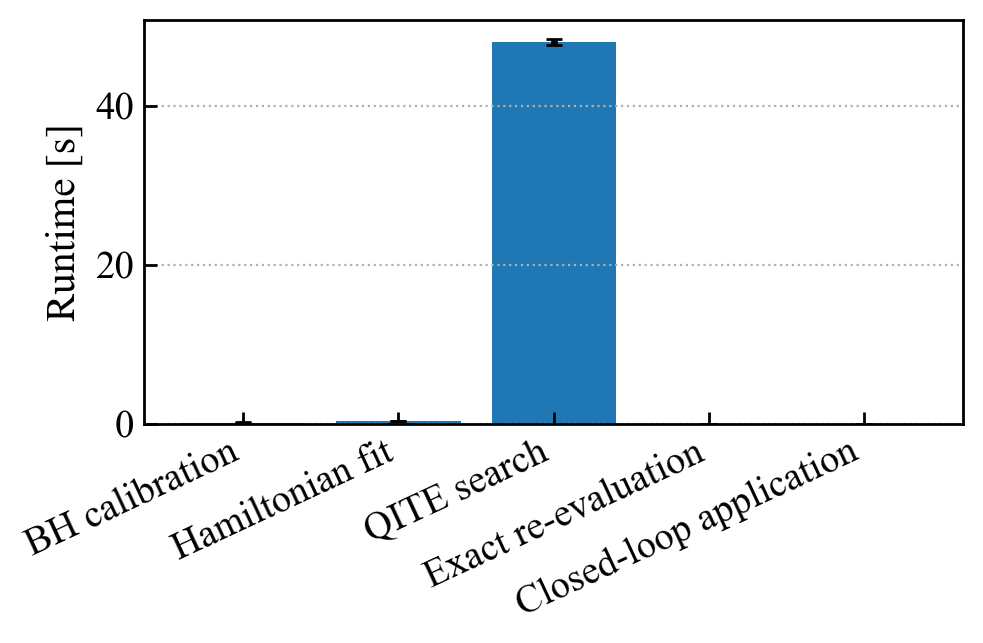

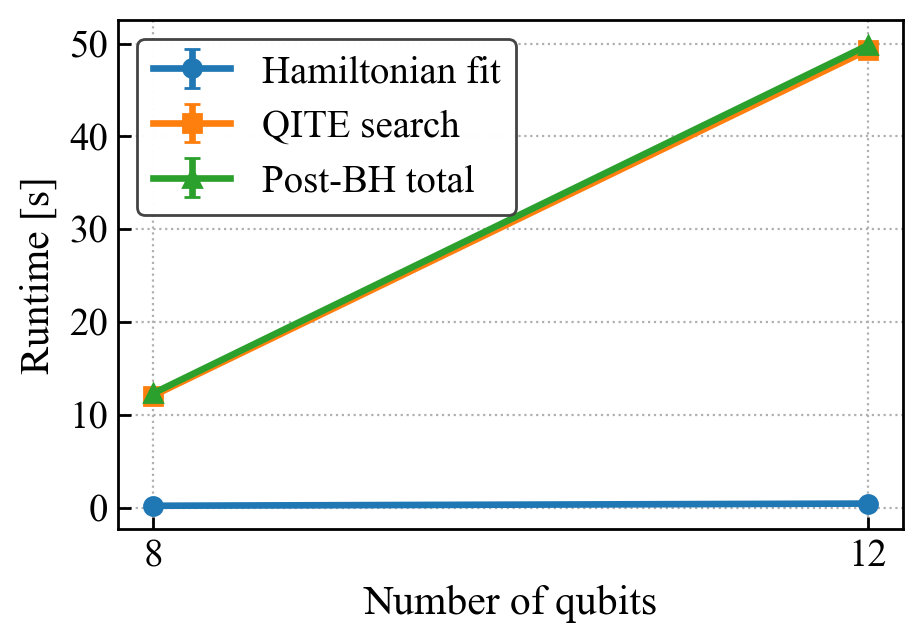

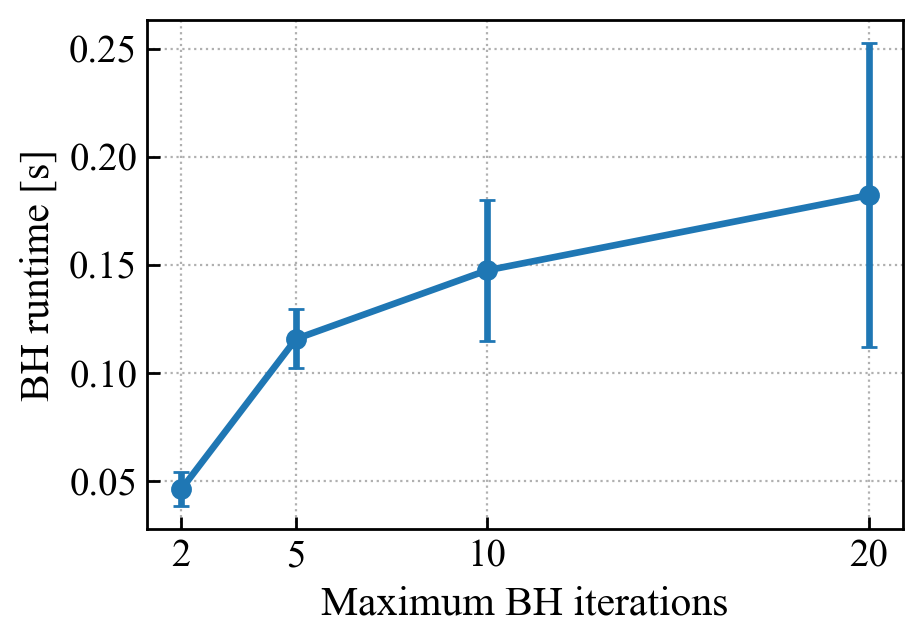

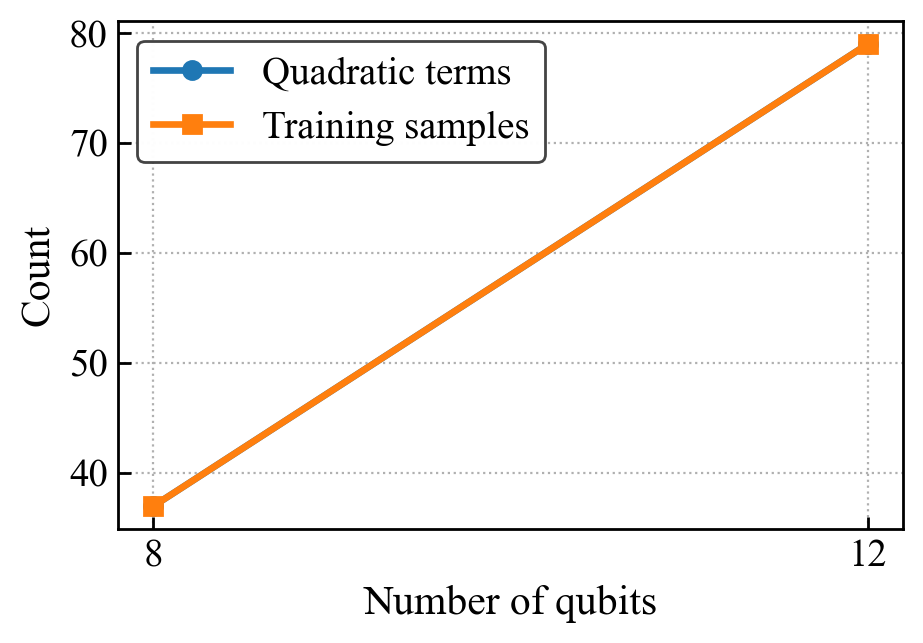


LATEX TABLES
\begin{table}[!t]
\caption{Stage-Wise Runtime of One Redesign Epoch}
\label{tab:stagewise_runtime}
\centering
\footnotesize
\begin{tabular}{l c}
\hline
\textbf{Stage} & \textbf{Runtime [s]} \\
\hline
BH calibration & $0.1835\pm0.0218$ \\
Hamiltonian fitting & $0.3961\pm0.0478$ \\
Encoded QITE search & $48.0854\pm0.3662$ \\
Exact nonlinear re-evaluation & $0.0055\pm0.0006$ \\
Closed-loop application & $0.0505\pm0.0094$ \\
Complete redesign epoch & $48.7211\pm0.3245$ \\
\hline
\end{tabular}
\end{table}

\begin{table}[!t]
\caption{Effect of Binary Resolution on QITE Runtime}
\label{tab:qite_resolution_runtime}
\centering
\footnotesize
\begin{tabular}{c c c c c}
\hline
\textbf{Bits} & \textbf{Qubits} & \textbf{Terms} & \textbf{Fit [s]} & \textbf{QITE [s]} \\
\hline
2 & 8 & 37 & 0.1948 & 12.0704 \\
3 & 12 & 79 & 0.4301 & 49.3017 \\
\hline
\end{tabular}
\end{table}

\begin{table}[!t]
\caption{Effect of Black-Hole Iterations on Runtime}
\label{tab:bh_iteration_runtime}
\centerin

In [4]:
complexity_results = run_computational_complexity_investigation()